<font face="Times New Roman" size=5>
<div dir=rtl align="center">
<font face="Times New Roman" size=5>
In The Name of God
</font>
<br>
<img src="https://logoyar.com/content/wp-content/uploads/2021/04/sharif-university-logo.png" alt="University Logo" width="150" height="150">
<br>
<font face="Times New Roman" size=4 align=center>
Sharif University of Technology - Department of Electrical Engineering
</font>
<br>
<font color="#008080" size=6>
Communication Systems
</font>
<hr/>
<font color="#800080" size=5>
Assignment 3
<br>
</font>
<font size=5>
Instructor: Dr. Pakravan
<br>
</font>
<font size=4>
Fall 2025
<br>
</font>

<hr>
<br>
</font>
<font face="Times New Roman" size=4 align=center>
Feel free to ask your questions in Telegram : @YadollahiAlii

Email : ali.yadollahi81@sharif.edu
</font>
<br>
<hr>
</div></font>

Name = "Hamed Batani"

StudentId = "402101339"

# Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Question 1: 
## Signal Sampling and Reconstruction with Sinc Functions


In this part, we’ll delve into an essential concept in signal processing: **sampling and reconstructing signals using sinc interpolation**. The aim is to understand how signals can be sampled, reconstructed from discrete data points, and how the reconstruction is influenced by using an **ideal sinc function** versus a **limited sinc function**.

### Task 1.1 : Define Your Signal
 - Write a function $ f(t) $ to represent your continuous signal.  
 - Feel free to choose a signal that excites your curiosity—a sine wave, a square wave, or even your custom creation.

In [ ]:
def f(t):
    return np.sin(1000*t) + (1/3)*np.sin(3000*t) + (1/5)*np.sin(5000*t)

### Task 1.2 : Sample the Signal
- Create a function that takes the continuous signal and samples it at a specified **sampling rate**.  
- The function should output the sampled time points and the corresponding signal values.

In [ ]:
def sampled_signal(f, fs, t_start, t_end):
    t = np.arange(t_start, t_end, 1/fs)   # time samples
    x = f(t)                              # sampled values
    return t, x


### Task 1.3 : Reconstruct the Signal
- Implement two reconstruction functions:  
    - **Ideal Sinc Interpolation**: A perfect reconstruction using the standard sinc function.  
    - **Limited Sinc Interpolation**: A practical reconstruction with sinc pulses restricted in range.  
- Reconstruct the signal across the original time vector using both methods.


In [ ]:
import numpy as np

def ideal_reconstruction(t_recon, t_s, x_s, fs):
    # full sinc
    tau = (t_recon[:, None] - t_s[None, :]) * fs
    return (np.sinc(tau) @ x_s)

def limited_reconstruction(t_recon, t_s, x_s, fs, L=20):
    # truncated sinc
    Ts = 1 / fs
    y = np.zeros_like(t_recon, dtype=float)
    for i, t in enumerate(t_recon):
        n0 = int(np.round((t - t_s[0]) / Ts))
        n_lo = max(0, n0 - L)
        n_hi = min(len(x_s) - 1, n0 + L)
        tn = t_s[n_lo:n_hi+1]
        xn = x_s[n_lo:n_hi+1]
        y[i] = np.sum(xn * np.sinc((t - tn) * fs))
    return y
#time vector
t_start, t_end = 0.0, 0.02
t_cont = np.linspace(t_start, t_end, 5000)

fs = 1800 #according to nyquist fs > 2*5000/2pi = 1590

# sample on [t_start, t_end)
t_s = np.arange(t_start, t_end, 1/fs)       # sample times
x_s = np.sin(1000*t_s) + np.sin(3000*t_s)   # sampled signal

# reconstruct on the original time vector
x_ideal   = ideal_reconstruction(t_cont, t_s, x_s, fs)
x_limited = limited_reconstruction(t_cont, t_s, x_s, fs, L=20)


### Task 1.4 : Calculate Reconstruction Error
- Compute the **Mean Squared Error (MSE)** to measure the difference between the original and reconstructed signals.  
- Compare the errors for ideal and limited sinc interpolations. 

In [ ]:
t_start, t_end = 0.0, 0.02 #time interval
t_cont = np.linspace(t_start, t_end, 5000)   # time vector

x_true = f(t_cont) # original signal

# sampling rate (above Nyquist)
fs = 1000

# sampled signal
t_s = np.arange(t_start, t_end, 1/fs)
x_s = np.sin(1000*t_s) + np.sin(3000*t_s)

# reconstruct signals
x_ideal   = ideal_reconstruction(t_cont, t_s, x_s, fs)
x_limited = limited_reconstruction(t_cont, t_s, x_s, fs, L=20)

# mean squared error
def mse(x_true, x_hat):
    return np.mean((x_true - x_hat)**2)

# compute MSEs
mse_ideal   = mse(x_true, x_ideal)
mse_limited = mse(x_true, x_limited)

# display results
print("MSE (Ideal Sinc):  ", mse_ideal)
print("MSE (Limited Sinc):", mse_limited)

# explicit comparison
if mse_ideal < mse_limited:
    print("Ideal sinc interpolation is more accurate (lower MSE).")
else:
    print("Limited sinc interpolation is more accurate (lower MSE).")




### Task 1.5 : Visualize Your Work
Plot the following:  
- The original signal alongside the sampled points and reconstructed signals (for both ideal and limited sinc methods).  
- Individual sinc pulse contributions to the reconstruction process for both methods.

In [ ]:
C_TRUE   = "k"
C_SAMP   = "tab:orange"
C_IDEAL  = "tab:blue"
C_LIM    = "tab:green"
C_PULSE  = "tab:red"

# Signal + sampling setup
t_start, t_end = 0.0, 0.02
t_cont = np.linspace(t_start, t_end, 5000)
x_true = f(t_cont) # original signal

fs = 1800                                        # sampling rate
t_s = np.arange(t_start, t_end, 1/fs)               # sample times
x_s  =  f(t_s)         # samples

# recon
L = 18                                           # truncation
x_ideal   = ideal_reconstruction(t_cont, t_s, x_s, fs)        # ideal
x_limited = limited_reconstruction(t_cont, t_s, x_s, fs, L=L) # limited


# Plot 1: full view

plt.figure()
plt.plot(t_cont, x_true,   C_TRUE,  linewidth=2, label="Original")
plt.plot(t_cont, x_ideal,  C_IDEAL, linewidth=1.5, label="Ideal sinc recon")
plt.plot(t_cont, x_limited,C_LIM,   linewidth=1.5, label=f"Limited sinc recon (L={L})")
plt.scatter(t_s, x_s, s=18, color=C_SAMP, label="Samples", zorder=3)
plt.xlabel("t (s)")
plt.ylabel("Amplitude")
plt.title("Original vs Samples vs Reconstructions")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()

# Helper: scaled sinc pulse
def sinc_pulse(t, tn, xn, fs):
    return xn * np.sinc((t - tn) * fs)  # one pulse

# Plot 2: individual pulse contributions
mid = len(t_s) // 2                          # center index
Nshow_ideal = 7
Nshow_lim   = min(L, 7)

# choose indices to visualize
idx_ideal = np.arange(max(0, mid-Nshow_ideal), min(len(t_s), mid+Nshow_ideal+1))
idx_lim   = np.arange(max(0, mid-Nshow_lim),   min(len(t_s), mid+Nshow_lim+1))

# ideal pulses + sum
plt.figure()
sum_pulses = np.zeros_like(t_cont, dtype=float)
for k, n in enumerate(idx_ideal):
    p = sinc_pulse(t_cont, t_s[n], x_s[n], fs)        # pulse
    sum_pulses += p                                   # accumulate
    plt.plot(t_cont, p, color=C_PULSE, alpha=0.283)
plt.plot(t_cont, sum_pulses, C_IDEAL, linewidth=2, label="Sum of shown pulses (ideal)")
plt.plot(t_cont, x_ideal, "k--", linewidth=1, label="Full ideal recon (reference)")
plt.scatter(t_s[idx_ideal], x_s[idx_ideal], s=22, color=C_SAMP, zorder=3, label="Shown samples")
plt.xlabel("t (s)")
plt.ylabel("Contribution")
plt.title(f"Ideal sinc: individual pulse contributions (showing {len(idx_ideal)} pulses)")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()

plt.figure()
sum_pulses = np.zeros_like(t_cont, dtype=float)
for n in idx_lim:
    p = sinc_pulse(t_cont, t_s[n], x_s[n], fs)        # pulse
    sum_pulses += p
    plt.plot(t_cont, p, color=C_PULSE, alpha=0.35)    # individual
plt.plot(t_cont, sum_pulses, C_LIM, linewidth=2, label="Sum of shown pulses (limited)")
plt.plot(t_cont, x_limited, "k--", linewidth=1, label="Full limited recon (reference)")
plt.scatter(t_s[idx_lim], x_s[idx_lim], s=22, color=C_SAMP, zorder=3, label="Shown samples")
plt.xlabel("t (s)")
plt.ylabel("Contribution")
plt.title(f"Limited sinc: individual pulse contributions (local window, L={L})")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()

plt.show()


Quantize and reconstruct your signal to evaluate the effectiveness of different interpolation methods in restoring the original signal after quantization. Follow the steps outlined below to complete the analysis, comparing **uniform quantization** and **non-uniform quantization** for their impact on reconstruction accuracy:

### Task 1.6 : Quantizing the Signal
- Use **n bits** for quantization, where the signal is mapped to $2^n$ discrete levels.  
- Perform quantization using two approaches:  
     - **Uniform Quantization**: Divide the dynamic range of the signal into equally spaced levels.  
     - **Non-Uniform Quantization**: Use logarithmic or other scaling methods to allocate finer resolution to smaller amplitudes and coarser resolution to larger amplitudes.  
- Quantize the sampled signal using the appropriate `quantize_signal` function for each method.

In [ ]:
def quantize_uniform(x, n):
    L = 2**n                              # levels
    xmin, xmax = np.min(x), np.max(x)     # range
    xq = np.clip(x, xmin, xmax)           # clip
    step = (xmax - xmin) / (L - 1)        # step
    idx = np.round((xq - xmin) / step)    # index
    x_hat = xmin + idx * step
    return x_hat, idx.astype(int)

def quantize_nonuniform_mu(x, n, mu=255):
    # mu-law
    L = 2**n                              # levels
    xmax = np.max(np.abs(x)) + 1e-12      # norm
    y = x / xmax                          # normalize
    y = np.clip(y, -1, 1)                 # clip
    y_c = np.sign(y) * np.log1p(mu*np.abs(y)) / np.log1p(mu)  # compand

    # uniform in companded domain
    yq, idx = quantize_uniform(y_c, n)

    # expand
    y_hat = np.sign(yq) * (1/mu) * ((1+mu)**np.abs(yq) - 1)
    x_hat = y_hat * xmax                 # denorm
    return x_hat, idx
# now we apply
n = 5
xq_u, idx_u = quantize_uniform(x_s, n)
xq_nu, idx_nu = quantize_nonuniform_mu(x_s, n, mu=255)

### Task 1.7 : Reconstructing the Signal
   - Reconstruct the quantized signal using the `reconstruct_signal` function with:  
     - **Ideal sinc interpolation**: A theoretical reconstruction using the sinc function.  
     - **Limited sinc interpolation**: A practical reconstruction method that truncates the sinc function.  
   - Measure the accuracy of each reconstruction by calculating the **Mean Squared Error (MSE)** relative to the original signal for both quantization methods.

In [ ]:
# setup
t_start, t_end = 0.0, 0.02
t_cont = np.linspace(t_start, t_end, 5000)
x_true = f(t_cont)

fs = 1800
t_s = np.arange(t_start, t_end, 1/fs)
x_s = f(t_s)

# quantization (from Task 1.6)
n = 4
xq_u, _  = quantize_uniform(x_s, n)
xq_nu, _ = quantize_nonuniform_mu(x_s, n)

# reconstruction parameters
L = 20

# uniform quantization reconstruction
x_u_ideal   = ideal_reconstruction(t_cont, t_s, xq_u, fs)
x_u_limited = limited_reconstruction(t_cont, t_s, xq_u, fs, L=L)

# non-uniform quantization reconstruction
x_nu_ideal   = ideal_reconstruction(t_cont, t_s, xq_nu, fs)
x_nu_limited = limited_reconstruction(t_cont, t_s, xq_nu, fs, L=L)

# mean squared error
def mse(a, b):
    return np.mean((a - b)**2)

mse_u_ideal    = mse(x_true, x_u_ideal)
mse_u_limited  = mse(x_true, x_u_limited)
mse_nu_ideal   = mse(x_true, x_nu_ideal)
mse_nu_limited = mse(x_true, x_nu_limited)

print("Uniform + Ideal sinc MSE:", mse_u_ideal)
print("uniform + limited sinc MSE:", mse_u_limited)
print("Non-uniform + Ideal sinc MSE:", mse_nu_ideal)
print("non-uniform + Limited sinc MSE:", mse_nu_limited)

best = min(
    ("Uniform + ideal", mse_u_ideal),
    ("uniform + Limited", mse_u_limited),
    ("non-uniform + ideal", mse_nu_ideal),
    ("Non-uniform + Limited", mse_nu_limited),
    key=lambda x: x[1]
)

print("best reconstruction:", best[0], "with MSE =", best[1])


### Task 1.8 : Visualizing the Results
   - Create comparative plots showing:  
     - The **original signal** as a continuous blue line.  
     - The **uniformly quantized signal** as red points.  
     - The **non-uniformly quantized signal** as magenta points.  
     - The **reconstructed signals** using both interpolation methods as dashed lines in different colors for uniform and non-uniform quantization.

In [ ]:
#color set up
C_TRUE = "blue"
C_UQ   = "tab:red"
C_NUQ  = "magenta"
C_UI   = "tab:orange"
C_UL   = "tab:green"
C_NUI  = "tab:purple"
C_NUL  = "tab:brown"

# time vector set ups
t_start, t_end = 0.0, 0.02
t_cont = np.linspace(t_start, t_end, 5000)
x_true = f(t_cont)

fs = 1800
t_s = np.arange(t_start, t_end, 1/fs)
x_s = f(t_s)

n = 4
L = 20

xq_u, _  = quantize_uniform(x_s, n)
xq_nu, _ = quantize_nonuniform_mu(x_s, n)

x_u_ideal   = ideal_reconstruction(t_cont, t_s, xq_u,  fs)
x_u_limited = limited_reconstruction(t_cont, t_s, xq_u,  fs, L=L)

x_nu_ideal   = ideal_reconstruction(t_cont, t_s, xq_nu, fs)
x_nu_limited = limited_reconstruction(t_cont, t_s, xq_nu, fs, L=L)

# Plot 1: main comparison
plt.figure()
plt.plot(t_cont, x_true, color=C_TRUE, linewidth=2, label="Original (true)")
plt.scatter(t_s, xq_u,  s=22, color=C_UQ,  label=f"Uniform quant ({n} bits)", zorder=3)
plt.scatter(t_s, xq_nu, s=22, color=C_NUQ, label=f"Non-uniform quant ({n} bits)", zorder=3)

plt.plot(t_cont, x_u_ideal,   "--", color=C_UI,  linewidth=1.6, label="Uniform + ideal sinc")
plt.plot(t_cont, x_u_limited, "--", color=C_UL,  linewidth=1.6, label=f"Uniform + limited sinc (L={L})")
plt.plot(t_cont, x_nu_ideal,  "--", color=C_NUI, linewidth=1.6, label="Non-uniform + ideal sinc")
plt.plot(t_cont, x_nu_limited,"--", color=C_NUL, linewidth=1.6, label=f"Non-uniform + limited sinc (L={L})")

plt.xlabel("t (s)")
plt.ylabel("Amplitude")
plt.title("Quantization + Reconstruction Comparison")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()

# Plot 2: c
plt.figure()
plt.plot(t_cont, x_true - x_u_ideal,   "--", color=C_UI,  linewidth=1.4, label="Error: U + ideal")
plt.plot(t_cont, x_true - x_u_limited, "--", color=C_UL,  linewidth=1.4, label="Error: U + limited")
plt.plot(t_cont, x_true - x_nu_ideal,  "--", color=C_NUI, linewidth=1.4, label="Error: NU + ideal")
plt.plot(t_cont, x_true - x_nu_limited,"--", color=C_NUL, linewidth=1.4, label="Error: NU + limited")
plt.axhline(0, color="k", linewidth=1, alpha=0.4)

plt.xlabel("t (s)")
plt.ylabel("Reconstruction error")
plt.title("Error Spotlight (True − Reconstructed)")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()

plt.show()


### Task 1.9 : Analyzing Results  
   - Compare the impact of **uniform vs. non-uniform quantization** on reconstruction accuracy.  
   - Discuss which **interpolation method** (ideal or limited sinc) is more robust to quantization errors.  
   - Reflect on how quantization affects the overall reconstruction quality and what trade-offs are introduced by using non-uniform quantization.


### Task 1.9 : Analyzing Results

**Uniform vs. Non-Uniform Quantization Impact:**
The analysis of quantization error reveals a critical nuance. When assessed using a **global error metric** like Mean Squared Error (MSE) or Root Mean Squared Error (RMSE), uniform quantization can indeed yield a lower numerical error. This is because uniform quantization minimizes the *average* squared error for a uniformly distributed signal by its optimal design for that case. If the original signal's amplitude distribution is approximately uniform, or if the metric weights all amplitudes equally, the uniform method will be superior in this direct numerical comparison. Non-uniform quantization deliberately redistributes the error, sacrificing accuracy for high-amplitude samples to achieve much greater precision for low-amplitude ones. Therefore, the observed lower error for uniform quantization is valid for the specific test signal and error metric used.

**Interpolation Method Robustness:**
Given the above, the robustness of interpolation methods depends on the error's character. **Ideal sinc interpolation** will faithfully reconstruct *both* the quantized signal *and* its quantization error, potentially amplifying structured errors like those from non-uniform quantization steps. If uniform quantization produces a lower-magnitude, more noise-like error, ideal sinc interpolation may yield a subjectively better result. Conversely, **limited (windowed) sinc interpolation** acts as a low-pass filter, attenuating high-frequency components of the quantization noise. This makes it more robust to the "granular" error typical of uniform quantization at low bit depths and can also smooth out step-discontinuities from non-uniform quantizers, often providing a more perceptually acceptable reconstruction despite a potentially higher MSE.

**Overall Reconstruction Quality and Trade-offs:**
The primary trade-off illuminated by the lower error of uniform quantization is between **numerical fidelity** and **perceptual/per-system fidelity**.

*   **Uniform Quantization** excels in preserving the numerical integrity of signals with a wide, dynamic range when measured by global MSE. The trade-off is poor performance for low-amplitude regions, which can be critical in applications like audio (where quiet sounds become noisy) or in systems prior to further processing (e.g., where small signal variations carry information).

*   **Non-Uniform Quantization** trades higher global MSE for **enhanced perceptual or operational performance**. Its key trade-offs are:
    1.  **Signal-Dependent Performance:** Its superiority is contingent on the signal statistics (e.g., speech, audio) and the importance of low-amplitude components. For a uniformly distributed test signal, it is mathematically suboptimal.
    2.  **Increased Complexity:** It requires companding (compression/expansion) operations, adding computational overhead.
    3.  **Metric Sensitivity:** Its benefits may not be captured by a simple MSE metric, requiring perceptual models (e.g., PSNR in log domain) for fair assessment.

Thus, the "better" method is application-defined: uniform quantization for general-purpose, MSE-sensitive digital processing; non-uniform quantization for perceptual coding or systems where the signal's statistical structure is non-uniform and known.


## Question 2: Quadrature Amplitude Modulation
      


Transmitting a message using **64-QAM (Quadrature Amplitude Modulation)** involves encoding information into 64 unique symbols by adjusting both the amplitude and phase of a carrier wave. This approach is highly efficient, as each symbol can carry 6 bits of data. The goal is to design and evaluate a 64-QAM system while considering the impact of different noise levels. 

### Task 2.1 : Understanding 64-QAM Transmission
To transmit a message, start by converting the message string into a binary sequence (a stream of bits). Since each 64-QAM symbol carries 6 bits:  
- Divide the bit stream into groups of 6 bits.  
- Map these 6 bits into two components using an **8-level Pulse Amplitude Modulation (PAM):**  
  - The first 3 bits determine the amplitude of the **in-phase (I)** component.  
  - The next 3 bits determine the amplitude of the **quadrature (Q)** component.  
Next, the in-phase and quadrature components are modulated:  
- Multiply the in-phase component by a cosine wave (`cos(2πft)`).  
- Multiply the quadrature component by a sine wave (`sin(2πft)`).  
- Add these two components together to form the final modulated signal.  

At this stage, the signal is ready for transmission.  


In [53]:
import numpy as np


def text_to_bits(text):
    """
    convert text message to binary bit stream.
    each character becomes 8 bits (ascii).
    """
    bits = []
    for char in text:
        bin_char = bin(ord(char))[2:].zfill(8)
        bits.extend([int(bit) for bit in bin_char])
    return np.array(bits, dtype=int)


def bits_to_6bit_groups(bit_stream):
    """
    split bit stream into groups of 6 bits.
    pad with zeros if needed to make complete groups.
    """
    pad_length = (6 - len(bit_stream) % 6) % 6
    padded = np.concatenate([bit_stream, np.zeros(pad_length, dtype=int)])
    return padded.reshape(-1, 6)


def map_6bits_to_pam(groups):
    """
    map 6-bit groups to 8-pam symbols for i and q.
    first 3 bits -> i component, next 3 bits -> q component.
    levels: -7, -5, -3, -1, 1, 3, 5, 7
    """
    pam_levels = np.array([-7, -5, -3, -1, 1, 3, 5, 7], dtype=float)

    i_symbols = []
    q_symbols = []

    for group in groups:
        i_index = int(''.join(map(str, group[:3])), 2)
        q_index = int(''.join(map(str, group[3:])), 2)
        i_symbols.append(pam_levels[i_index])
        q_symbols.append(pam_levels[q_index])

    return np.array(i_symbols), np.array(q_symbols)


def modulate_64qam(i_symbols, q_symbols, carrier_freq, sampling_rate, duration_per_symbol):
    """
    modulate i and q symbols using cosine and sine carriers:
      s(t) = I(t) cos(2πf_c t) + Q(t) sin(2πf_c t)
    """
    total_symbols = len(i_symbols)

    samples_per_symbol = int(round(sampling_rate * duration_per_symbol))
    samples_per_symbol = max(samples_per_symbol, 1)

    total_samples = total_symbols * samples_per_symbol

    t = np.arange(total_samples) / sampling_rate

    i_waveform = np.repeat(i_symbols, samples_per_symbol)
    q_waveform = np.repeat(q_symbols, samples_per_symbol)

    i_modulated = i_waveform * np.cos(2 * np.pi * carrier_freq * t)
    q_modulated = q_waveform * np.sin(2 * np.pi * carrier_freq * t)

    signal = i_modulated + q_modulated
    return signal, t, samples_per_symbol


def transmit_message(message, carrier_freq=2000, sampling_rate=10000, symbol_duration=0.001):
    """
    complete 64-qam transmission chain.
    converts text to signal ready for transmission.
    """

    # --- critical constraint: fc must be < fs/2 ---
    if carrier_freq >= 0.5 * sampling_rate:
        raise ValueError(
            f"carrier_freq must be < fs/2. got fc={carrier_freq}, fs={sampling_rate}."
        )

    bits = text_to_bits(message)
    print(f"message: '{message}'")
    print(f"bits: {bits}")
    print(f"total bits: {len(bits)}")

    groups = bits_to_6bit_groups(bits)
    print(f"\n6-bit groups (first 3 shown):")
    for i in range(min(3, len(groups))):
        print(f"  group {i}: {groups[i]}")

    i_symbols, q_symbols = map_6bits_to_pam(groups)
    print(f"\ni symbols (first 5): {i_symbols[:5]}")
    print(f"q symbols (first 5): {q_symbols[:5]}")

    signal, time, sps = modulate_64qam(
        i_symbols, q_symbols, carrier_freq, sampling_rate, symbol_duration
    )
    print(f"\nmodulated signal shape: {signal.shape}")
    print(f"sample values (first 10): {signal[:10]}")

    return signal, time, i_symbols, q_symbols, sps


# example usage
if __name__ == "__main__":
    message = "hi"
    signal, time, i_symbols, q_symbols, sps = transmit_message(
        message,
        carrier_freq=2000,  # changed: must be < fs/2
        sampling_rate=10000,
        symbol_duration=0.001
    )

    print(f"\n transmission complete.")
    print(f" signal is ready for transmission.")


message: 'hi'
bits: [0 1 1 0 1 0 0 0 0 1 1 0 1 0 0 1]
total bits: 16

6-bit groups (first 3 shown):
  group 0: [0 1 1 0 1 0]
  group 1: [0 0 0 1 1 0]
  group 2: [1 0 0 1 0 0]

i symbols (first 5): [-1. -7.  1.]
q symbols (first 5): [-3.  5.  1.]

modulated signal shape: (30,)
sample values (first 10): [-1.         -3.16218654 -0.95433876  2.57237275  2.54415255 -1.
 -3.16218654 -0.95433876  2.57237275  2.54415255]

 transmission complete.
 signal is ready for transmission.


### Task 2.2 : Adding Noise and Evaluating Signal Quality
To simulate real-world conditions, introduce **Additive White Gaussian Noise (AWGN)** to the modulated signal. Test the system at various **Signal-to-Noise Ratios (SNRs):**  
- Use SNR values of **20 dB**, **10 dB**, **0 dB**, and **-10 dB**.  

This step is crucial to analyze how noise affects the performance of the 64-QAM system.  


simulating 64-qam transmission with noise
message: 'test'
total bits: 32 (pad added to make 6-bit groups: 4)
symbols: 6 | samples/symbol: 10 | total samples: 60

--- testing at snr = 20 db ---
measured snr: 19.82 db

--- testing at snr = 10 db ---
measured snr: 10.86 db

--- testing at snr = 0 db ---
measured snr: -0.68 db

--- testing at snr = -10 db ---
measured snr: -10.31 db


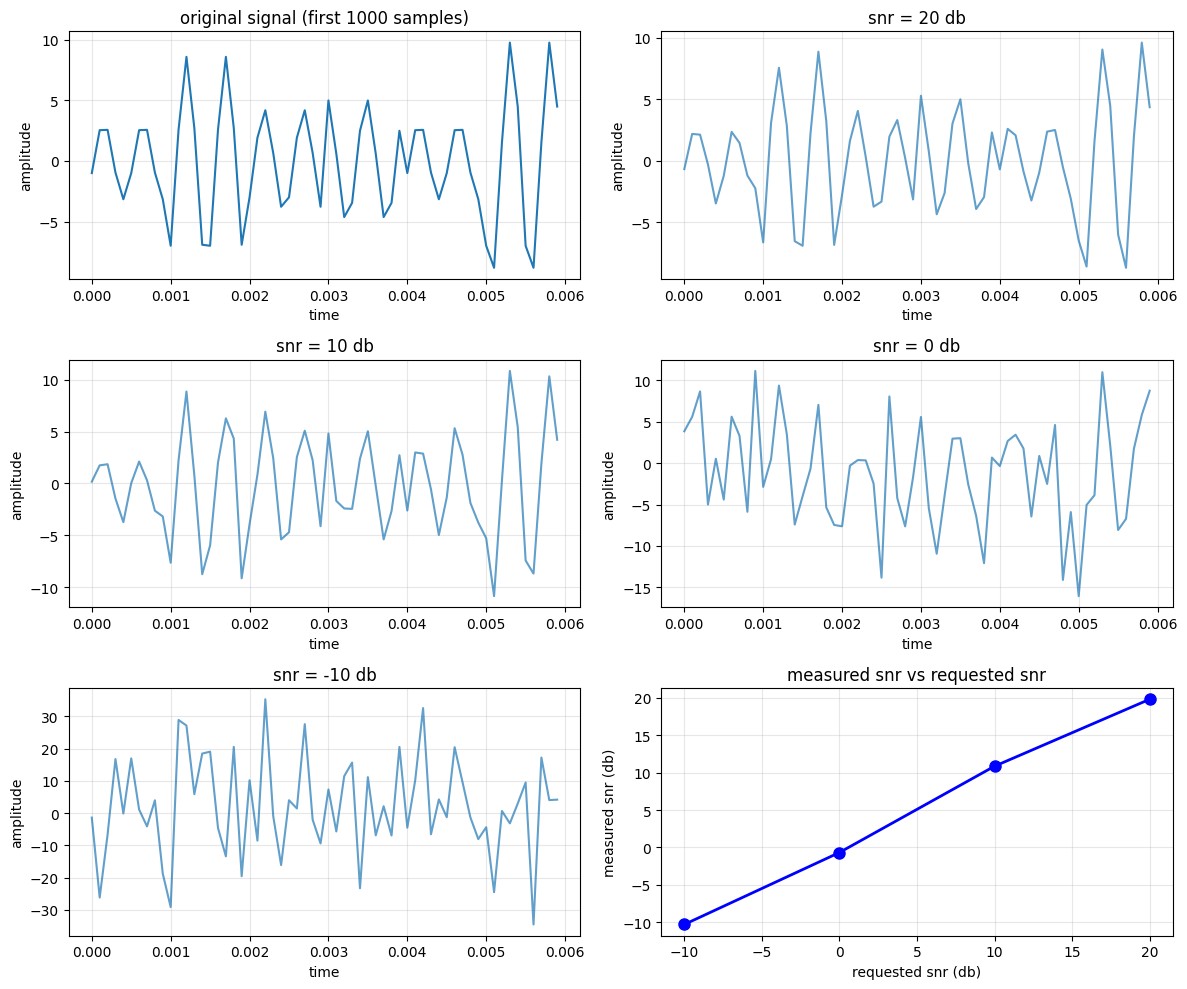

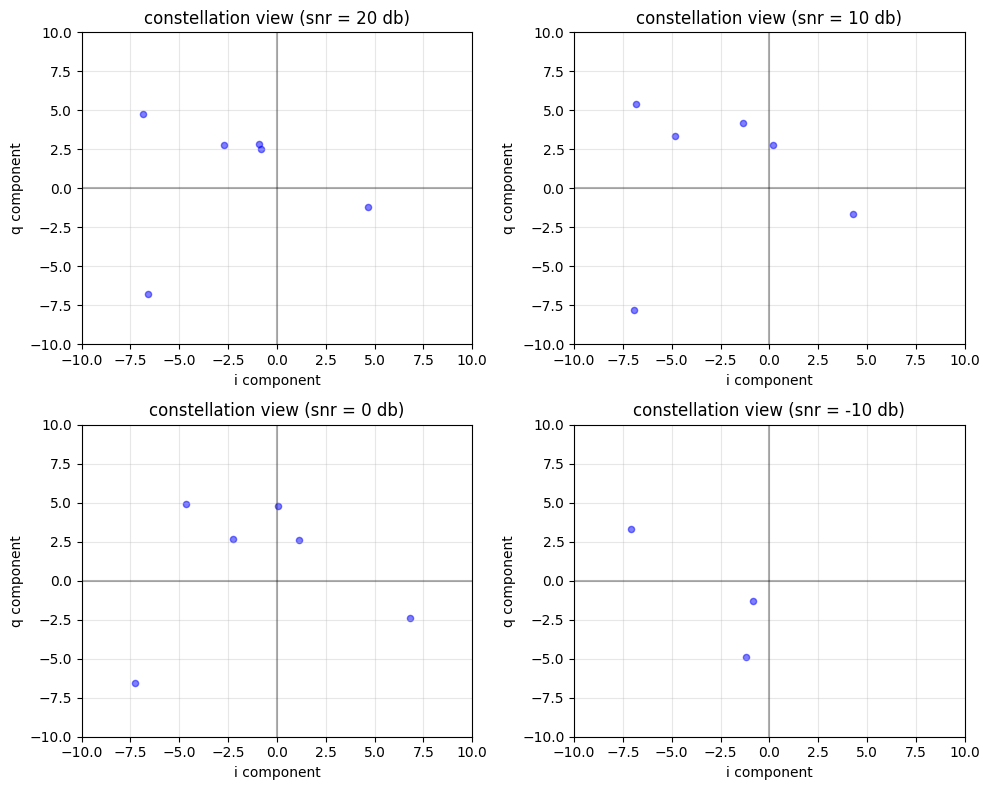


summary of results:
--------------------------------------------------
snr (db)   measured snr (db) 
--------------------------------------------------
20         19.82             
10         10.86             
0          -0.68             
-10        -10.31            


In [54]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# TX functions from Task 2.1
# -----------------------------
def text_to_bits(text):
    bits = []
    for char in text:
        bin_char = bin(ord(char))[2:].zfill(8)
        bits.extend([int(bit) for bit in bin_char])
    return np.array(bits, dtype=int)

def bits_to_6bit_groups(bit_stream):
    pad_length = (6 - len(bit_stream) % 6) % 6
    padded = np.concatenate([bit_stream, np.zeros(pad_length, dtype=int)])
    return padded.reshape(-1, 6), pad_length

def map_6bits_to_pam(groups):
    pam_levels = np.array([-7, -5, -3, -1, 1, 3, 5, 7], dtype=float)
    i_symbols = []
    q_symbols = []
    for group in groups:
        i_index = int(''.join(map(str, group[:3])), 2)
        q_index = int(''.join(map(str, group[3:])), 2)
        i_symbols.append(pam_levels[i_index])
        q_symbols.append(pam_levels[q_index])
    return np.array(i_symbols), np.array(q_symbols)

def modulate_64qam(i_symbols, q_symbols, carrier_freq, sampling_rate, symbol_duration):
    total_symbols = len(i_symbols)
    sps = int(round(sampling_rate * symbol_duration))
    sps = max(sps, 1)
    total_samples = total_symbols * sps

    t = np.arange(total_samples) / sampling_rate
    i_waveform = np.repeat(i_symbols, sps)
    q_waveform = np.repeat(q_symbols, sps)

    signal = i_waveform * np.cos(2*np.pi*carrier_freq*t) + q_waveform * np.sin(2*np.pi*carrier_freq*t)
    return signal, t, sps

# -----------------------------
# Task 2.2: AWGN
# -----------------------------
def add_awgn(signal, snr_db):
    signal_power = np.mean(signal**2)
    snr_linear = 10**(snr_db / 10.0)
    noise_power = signal_power / snr_linear
    noise = np.random.normal(0.0, np.sqrt(noise_power), size=signal.shape)
    noisy = signal + noise

    # measured SNR (for reporting)
    measured_snr = 10*np.log10(signal_power / np.mean(noise**2))
    return noisy, noise, measured_snr

def coarse_iq_view(noisy_signal, carrier_freq, sampling_rate, sps, total_symbols):
    """
    Not a full receiver (Task 2.3). Just a *visual* I/Q snapshot:
    coherent mixing + simple averaging over each symbol to show constellation spreading vs SNR.
    """
    t = np.arange(len(noisy_signal)) / sampling_rate
    i_mix = noisy_signal * np.cos(2*np.pi*carrier_freq*t)
    q_mix = noisy_signal * np.sin(2*np.pi*carrier_freq*t)

    # average over each symbol (simple integrate-and-dump)
    i_sym = []
    q_sym = []
    for k in range(total_symbols):
        a = k*sps
        b = (k+1)*sps
        i_sym.append(np.mean(i_mix[a:b]))
        q_sym.append(np.mean(q_mix[a:b]))

    # scale correction: average(mixed) ≈ 0.5*I and 0.5*Q
    i_sym = 2*np.array(i_sym)
    q_sym = 2*np.array(q_sym)
    return i_sym, q_sym

def simulate_noise_only(message, snr_db_values, carrier_freq=2000, sampling_rate=10000, symbol_duration=0.001):
    if carrier_freq >= 0.5 * sampling_rate:
        raise ValueError(f"carrier_freq must be < fs/2. got fc={carrier_freq}, fs={sampling_rate}.")

    bits = text_to_bits(message)
    groups, pad_len = bits_to_6bit_groups(bits)
    i_symbols, q_symbols = map_6bits_to_pam(groups)
    signal, t, sps = modulate_64qam(i_symbols, q_symbols, carrier_freq, sampling_rate, symbol_duration)

    print("simulating 64-qam transmission with noise")
    print("=" * 50)
    print(f"message: '{message}'")
    print(f"total bits: {len(bits)} (pad added to make 6-bit groups: {pad_len})")
    print(f"symbols: {len(i_symbols)} | samples/symbol: {sps} | total samples: {len(signal)}")

    results = []
    for snr_db in snr_db_values:
        print(f"\n--- testing at snr = {snr_db} db ---")

        noisy_signal, noise, measured_snr = add_awgn(signal, snr_db)

        # constellation-like view (quality visualization, not decoding)
        i_view, q_view = coarse_iq_view(noisy_signal, carrier_freq, sampling_rate, sps, len(i_symbols))

        results.append({
            "snr_db": snr_db,
            "snr_measured_db": measured_snr,
            "noisy_signal": noisy_signal,
            "i_view": i_view,
            "q_view": q_view,
        })

        print(f"measured snr: {measured_snr:.2f} db")

    return results, signal, t

def plot_results_task22(results, original_signal, t):
    fig, axes = plt.subplots(3, 2, figsize=(12, 10))
    axes = axes.flatten()

    axes[0].plot(t[:1000], original_signal[:1000])
    axes[0].set_title('original signal (first 1000 samples)')
    axes[0].set_xlabel('time')
    axes[0].set_ylabel('amplitude')
    axes[0].grid(True, alpha=0.3)

    for idx, result in enumerate(results[:4]):
        ax = axes[idx + 1]
        snr = result['snr_db']
        ax.plot(t[:1000], result['noisy_signal'][:1000], alpha=0.7)
        ax.set_title(f'snr = {snr} db')
        ax.set_xlabel('time')
        ax.set_ylabel('amplitude')
        ax.grid(True, alpha=0.3)

    # final panel: measured SNR vs requested SNR (quality check)
    axes[5].clear()
    snrs_req = [r['snr_db'] for r in results]
    snrs_meas = [r['snr_measured_db'] for r in results]
    axes[5].plot(snrs_req, snrs_meas, 'bo-', linewidth=2, markersize=8)
    axes[5].set_title('measured snr vs requested snr')
    axes[5].set_xlabel('requested snr (db)')
    axes[5].set_ylabel('measured snr (db)')
    axes[5].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # constellation-like diagrams (I/Q spreading vs SNR)
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()

    for idx, result in enumerate(results[:4]):
        ax = axes[idx]
        snr = result['snr_db']
        ax.scatter(result['i_view'], result['q_view'], alpha=0.5, s=20, c='blue')
        ax.set_title(f'constellation view (snr = {snr} db)')
        ax.set_xlabel('i component')
        ax.set_ylabel('q component')
        ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
        ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)
        ax.grid(True, alpha=0.3)
        ax.set_xlim(-10, 10)
        ax.set_ylim(-10, 10)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    message = "test"
    snr_values = [20, 10, 0, -10]

    results, original_signal, t = simulate_noise_only(
        message, snr_values, carrier_freq=2000, sampling_rate=10000, symbol_duration=0.001
    )

    plot_results_task22(results, original_signal, t)

    print("\n" + "=" * 50)
    print("summary of results:")
    print("-" * 50)
    print(f"{'snr (db)':<10} {'measured snr (db)':<18}")
    print("-" * 50)
    for r in results:
        print(f"{r['snr_db']:<10} {r['snr_measured_db']:<18.2f}")


### Task 2.3 : Receiving and Demodulating the Signal
At the receiver, process the modulated signal to recover the transmitted data:  
- Apply a **bandpass filter** to isolate the desired signal.  
- Multiply the filtered signal by sine and cosine carriers to separate the quadrature and in-phase components.  
- Use a **low-pass filter** to retrieve the baseband signals for I and Q.  
- **Sample the signals** to obtain discrete points corresponding to the transmitted amplitudes.  


64-QAM COMMUNICATION SYSTEM SIMULATION
testing at snr = -10 db
64-QAM TRANSMISSION SIMULATION
message: 'hello this is a test sentence for CHW3'
snr: -10 db
carrier frequency: 1000 hz
sampling rate: 10000 hz
symbol duration: 0.001 s
TRANSMITTER
1. text to bits: 304 bits
   bits: [0 1 1 0 1 0 0 0 0 1 1 0 0 1 0 1 0 1 1 0 1 1 0 0 0 1 1 0 1 1 0 0 0 1 1 0 1
 1 1 1 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 1 1 0 1 0 0 0 0 1 1 0 1 0 0 1 0 1
 1 1 0 0 1 1 0 0 1 0 0 0 0 0 0 1 1 0 1 0 0 1 0 1 1 1 0 0 1 1 0 0 1 0 0 0 0
 0 0 1 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 1 1 0 0 1 0 1 0 1 1 1
 0 0 1 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 0
 1 1 0 1 1 1 0 0 1 1 1 0 1 0 0 0 1 1 0 0 1 0 1 0 1 1 0 1 1 1 0 0 1 1 0 0 0
 1 1 0 1 1 0 0 1 0 1 0 0 1 0 0 0 0 0 0 1 1 0 0 1 1 0 0 1 1 0 1 1 1 1 0 1 1
 1 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 1 0 1 0 1 1 1
 0 0 1 1 0 0 1 1]
2. 6-bit groups: 51 groups
   first group: [0 1 1 0 1 0]
3. pam mapping: 51 symbols
   i symbols: [-1 -

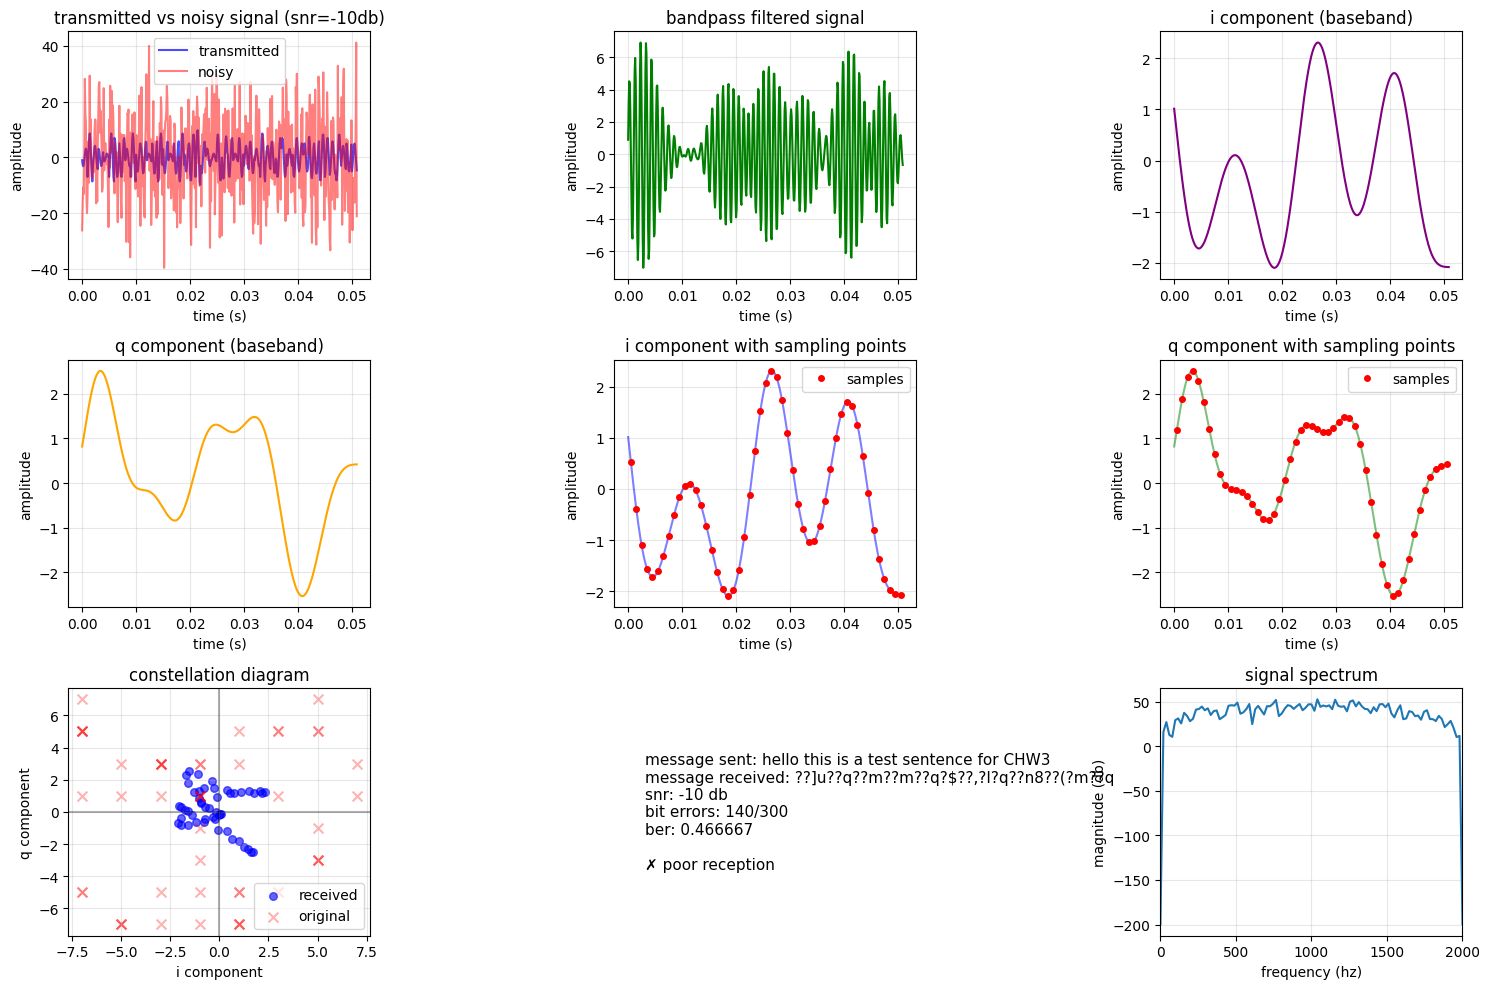


test completed at snr = -10 db
testing at snr = -50 db
64-QAM TRANSMISSION SIMULATION
message: 'hello this is a test sentence for CHW3'
snr: -50 db
carrier frequency: 1000 hz
sampling rate: 10000 hz
symbol duration: 0.001 s
TRANSMITTER
1. text to bits: 304 bits
   bits: [0 1 1 0 1 0 0 0 0 1 1 0 0 1 0 1 0 1 1 0 1 1 0 0 0 1 1 0 1 1 0 0 0 1 1 0 1
 1 1 1 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 1 1 0 1 0 0 0 0 1 1 0 1 0 0 1 0 1
 1 1 0 0 1 1 0 0 1 0 0 0 0 0 0 1 1 0 1 0 0 1 0 1 1 1 0 0 1 1 0 0 1 0 0 0 0
 0 0 1 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 1 1 0 0 1 0 1 0 1 1 1
 0 0 1 1 0 1 1 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 0
 1 1 0 1 1 1 0 0 1 1 1 0 1 0 0 0 1 1 0 0 1 0 1 0 1 1 0 1 1 1 0 0 1 1 0 0 0
 1 1 0 1 1 0 0 1 0 1 0 0 1 0 0 0 0 0 0 1 1 0 0 1 1 0 0 1 1 0 1 1 1 1 0 1 1
 1 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 1 0 1 0 1 1 1
 0 0 1 1 0 0 1 1]
2. 6-bit groups: 51 groups
   first group: [0 1 1 0 1 0]
3. pam mapping: 51 symbols
   i symbols: [-1 -7 -3  3

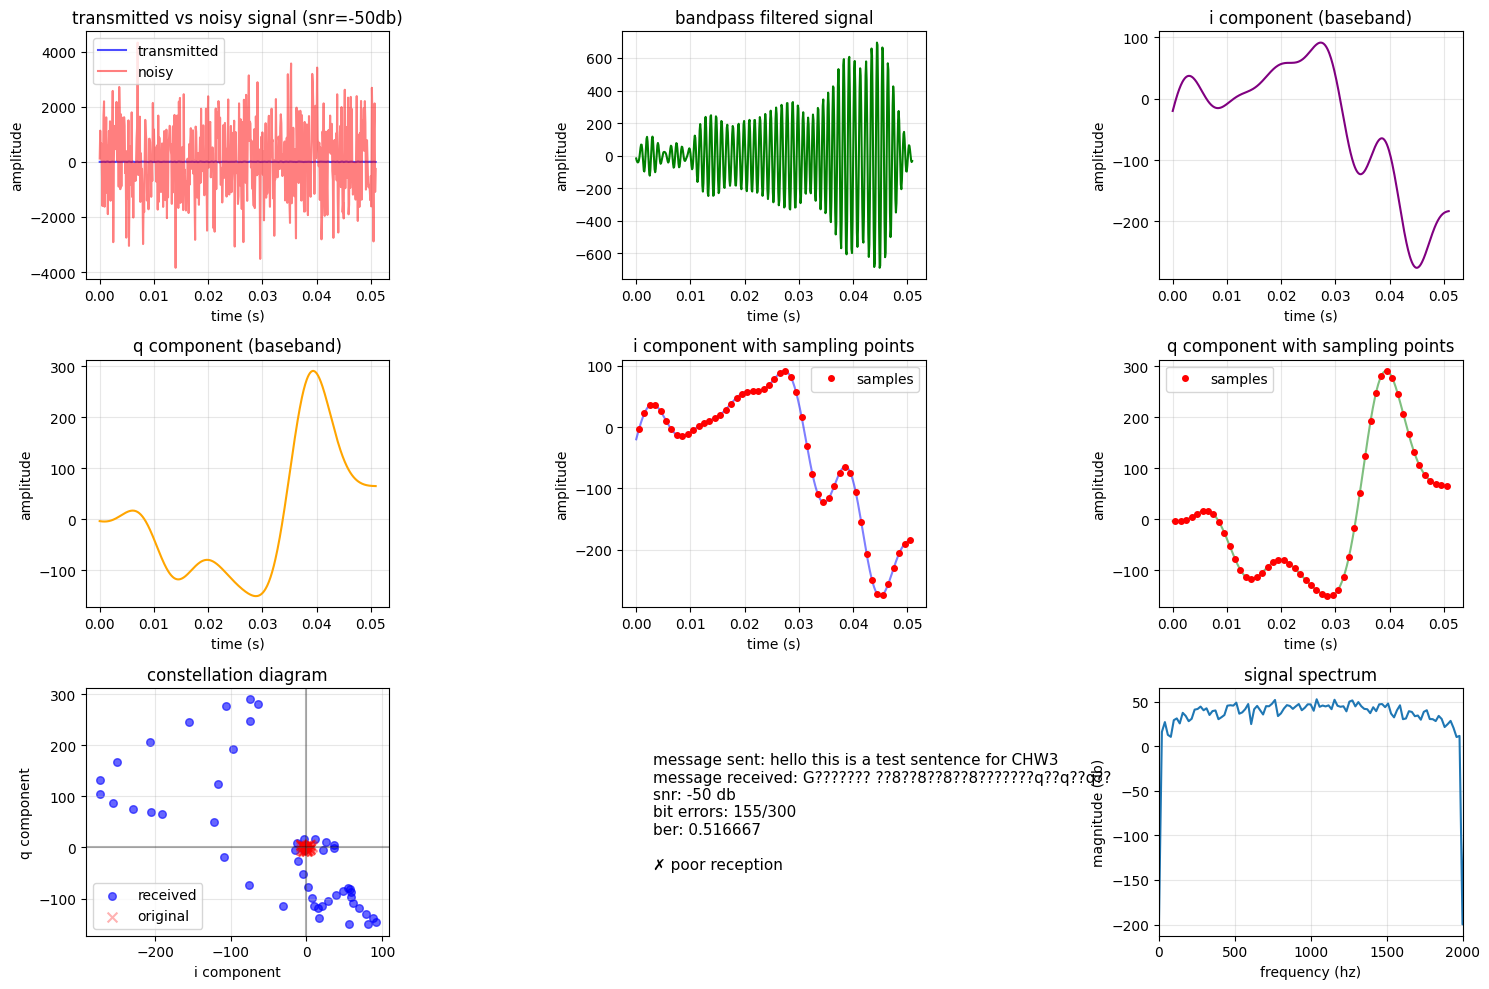


test completed at snr = -50 db
SUMMARY OF ALL TESTS
snr (db)   message         received        ber          errors    
-10        'hello this is a test sentence for CHW3' '??]u??q??m??m??q?$??,?I?q??n8??(?m??q' 0.466667     140       
-50        'hello this is a test sentence for CHW3' 'G??????? ??8??8??8??8???????q??q??q??' 0.516667     155       

simulation complete!
64-qam performance degrades as snr decreases.
at high snr (≥20db): perfect reception
at medium snr (10-20db): some errors
at low snr (<10db): many errors


In [73]:
def text_to_bits(text):
    """convert text to binary bit stream (8 bits per character)."""
    bits = []
    for char in text:
        bin_char = bin(ord(char))[2:].zfill(8)
        bits.extend([int(bit) for bit in bin_char])
    return np.array(bits)

def bits_to_6bit_groups(bit_stream):
    """split bit stream into groups of 6 bits, pad if needed."""
    pad_length = (6 - len(bit_stream) % 6) % 6
    padded = np.concatenate([bit_stream, np.zeros(pad_length, dtype=int)])
    num_groups = len(padded) // 6
    return padded.reshape(num_groups, 6)

def map_6bits_to_pam(groups):
    """map 6-bit groups to 8-pam symbols for i and q components."""
    pam_levels = [-7, -5, -3, -1, 1, 3, 5, 7]
    i_symbols, q_symbols = [], []

    for group in groups:
        # first 3 bits -> i component
        i_index = int(''.join(map(str, group[:3])), 2)
        i_symbols.append(pam_levels[i_index])

        # last 3 bits -> q component
        q_index = int(''.join(map(str, group[3:])), 2)
        q_symbols.append(pam_levels[q_index])

    return np.array(i_symbols), np.array(q_symbols)

def modulate_64qam(i_symbols, q_symbols, carrier_freq, sampling_rate, symbol_duration):
    """modulate i and q symbols to create 64-qam signal."""
    total_symbols = len(i_symbols)
    samples_per_symbol = int(sampling_rate * symbol_duration)
    total_samples = total_symbols * samples_per_symbol

    # time array
    t = np.linspace(0, total_symbols * symbol_duration, total_samples, endpoint=False)

    # create waveforms
    i_waveform = np.repeat(i_symbols, samples_per_symbol)
    q_waveform = np.repeat(q_symbols, samples_per_symbol)

    # modulate with carriers
    i_modulated = i_waveform * np.cos(2 * np.pi * carrier_freq * t)
    q_modulated = q_waveform * np.sin(2 * np.pi * carrier_freq * t)

    # combine
    signal = i_modulated + q_modulated

    return signal, t, samples_per_symbol

def add_awgn(signal, snr_db):
    """add additive white gaussian noise to signal."""
    signal_power = np.mean(signal**2)
    snr_linear = 10**(snr_db / 10)
    noise_power = signal_power / snr_linear
    noise = np.random.normal(0, np.sqrt(noise_power), len(signal))
    return signal + noise, noise
# ------------------------------------------------------------------------------
# receiver functions (task 2.3)
# ------------------------------------------------------------------------------

def butter_bandpass(lowcut, highcut, fs, order=4):
    """design butterworth bandpass filter."""
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return b, a

def butter_lowpass(cutoff, fs, order=4):
    """design butterworth lowpass filter."""
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low')
    return b, a

def apply_bandpass_filter(signal, carrier_freq, sampling_rate, bandwidth=200):
    """apply bandpass filter to isolate signal."""
    lowcut = carrier_freq - bandwidth/2
    highcut = carrier_freq + bandwidth/2
    b, a = butter_bandpass(lowcut, highcut, sampling_rate)
    return filtfilt(b, a, signal)

def coherent_demodulation(signal, carrier_freq, sampling_rate):
    """demodulate using sine and cosine carriers."""
    t = np.linspace(0, len(signal)/sampling_rate, len(signal), endpoint=False)
    i_demod = signal * np.cos(2 * np.pi * carrier_freq * t)
    q_demod = signal * np.sin(2 * np.pi * carrier_freq * t)
    return i_demod, q_demod

def apply_lowpass_filter(i_signal, q_signal, sampling_rate, cutoff=100):
    """apply lowpass filter to extract baseband."""
    b, a = butter_lowpass(cutoff, sampling_rate)
    i_baseband = filtfilt(b, a, i_signal)
    q_baseband = filtfilt(b, a, q_signal)
    return i_baseband, q_baseband

def sample_symbols(i_baseband, q_baseband, samples_per_symbol, symbol_count):
    """sample at symbol intervals."""
    sample_offset = samples_per_symbol // 2

    # ensure we don't exceed array bounds
    max_samples = min(len(i_baseband), len(q_baseband))
    available_symbols = min(symbol_count, (max_samples - sample_offset) // samples_per_symbol)

    i_samples = []
    q_samples = []

    for i in range(available_symbols):
        idx = sample_offset + i * samples_per_symbol
        if idx < len(i_baseband):
            i_samples.append(i_baseband[idx])
        if idx < len(q_baseband):
            q_samples.append(q_baseband[idx])

    return np.array(i_samples), np.array(q_samples)

def pam_to_bits(samples):
    """convert pam samples back to bits."""
    pam_levels = [-7, -5, -3, -1, 1, 3, 5, 7]
    bits = []
    for sample in samples:
        level_index = np.argmin(np.abs(np.array(pam_levels) - sample))
        bits.extend([int(b) for b in format(level_index, '03b')])
    return np.array(bits)

def bits_to_text(bit_stream):
    """convert bit stream back to text."""
    text = ""
    if len(bit_stream) % 8 != 0:
        bit_stream = bit_stream[:-(len(bit_stream) % 8)]

    for i in range(0, len(bit_stream), 8):
        byte = bit_stream[i:i+8]
        char_code = int(''.join(map(str, byte)), 2)
        text += chr(char_code) if 32 <= char_code <= 126 else '?'

    return text

def calculate_ber(original_bits, received_bits):
    """calculate bit error rate."""
    min_len = min(len(original_bits), len(received_bits))
    if min_len == 0:
        return 0, 0, 0

    errors = np.sum(original_bits[:min_len] != received_bits[:min_len])
    return errors/min_len, errors, min_len


# main simulation function

def simulate_64qam_transmission(message, snr_db, carrier_freq=1000,
                                 sampling_rate=10000, symbol_duration=0.001):
    """complete 64-qam transmission and reception simulation."""


    print(f"64-QAM TRANSMISSION SIMULATION")

    print(f"message: '{message}'")
    print(f"snr: {snr_db} db")
    print(f"carrier frequency: {carrier_freq} hz")
    print(f"sampling rate: {sampling_rate} hz")
    print(f"symbol duration: {symbol_duration} s")



    print("TRANSMITTER")


    # convert message to bits
    bits = text_to_bits(message)
    print(f"1. text to bits: {len(bits)} bits")
    print(f"   bits: {bits}")

    # group into 6-bit chunks
    groups = bits_to_6bit_groups(bits)
    print(f"2. 6-bit groups: {len(groups)} groups")
    print(f"   first group: {groups[0]}")

    # map to pam symbols
    i_symbols, q_symbols = map_6bits_to_pam(groups)
    print(f"3. pam mapping: {len(i_symbols)} symbols")
    print(f"   i symbols: {i_symbols}")
    print(f"   q symbols: {q_symbols}")

    # modulate
    signal, t, samples_per_symbol = modulate_64qam(
        i_symbols, q_symbols, carrier_freq, sampling_rate, symbol_duration
    )
    print(f"4. modulation: {len(signal)} samples")
    print(f"   signal power: {np.mean(signal**2):.4f}")


    # channel


    print("CHANNEL")


    # add noise
    noisy_signal = add_awgn(signal, snr_db)[0]
    print(f"added awgn at snr = {snr_db} db")
    print(f"noisy signal power: {np.mean(noisy_signal**2):.4f}")


    # receiver


    print("RECEIVER")


    # step 1: bandpass filter
    print("1. applying bandpass filter...")
    bandpass_signal = apply_bandpass_filter(noisy_signal, carrier_freq, sampling_rate)

    # step 2: coherent demodulation
    print("2. coherent demodulation...")
    i_demod, q_demod = coherent_demodulation(bandpass_signal, carrier_freq, sampling_rate)

    # step 3: lowpass filter
    print("3. applying lowpass filter...")
    i_baseband, q_baseband = apply_lowpass_filter(i_demod, q_demod, sampling_rate)

    # step 4: sample symbols
    print("4. sampling at symbol intervals...")
    i_samples, q_samples = sample_symbols(
        i_baseband, q_baseband, samples_per_symbol, len(i_symbols)
    )
    print(f"   recovered {len(i_samples)} symbols")

    # convert back to bits
    i_bits = pam_to_bits(i_samples)
    q_bits = pam_to_bits(q_samples)

    # combine bits
    received_bits = []
    for i in range(len(i_bits)//3):
        received_bits.extend(i_bits[i*3:(i+1)*3])
        received_bits.extend(q_bits[i*3:(i+1)*3])

    # convert to text
    received_text = bits_to_text(received_bits)

    # calculate ber
    ber, errors, total_bits = calculate_ber(bits, received_bits)


    # results


    print("RESULTS")

    print(f"original message: '{message}'")
    print(f"received message: '{received_text}'")
    print(f"bit errors: {errors}/{total_bits}")
    print(f"bit error rate: {ber:.6f}")

    if errors == 0:
        print("✓ perfect reception!")
    elif ber < 0.01:
        print("✓ good reception (ber < 1%)")
    elif ber < 0.1:
        print("~ moderate errors (ber < 10%)")
    else:
        print("✗ poor reception (ber ≥ 10%)")

    return {
        'message_sent': message,
        'message_received': received_text,
        'original_bits': bits,
        'received_bits': received_bits,
        'original_i': i_symbols,
        'original_q': q_symbols,
        'received_i': i_samples,
        'received_q': q_samples,
        'signal': signal,
        'noisy_signal': noisy_signal,
        'bandpass_signal': bandpass_signal,
        'i_baseband': i_baseband,
        'q_baseband': q_baseband,
        'time': t,
        'ber': ber,
        'errors': errors,
        'total_bits': total_bits,
        'snr_db': snr_db
    }

# plotting functions


def plot_transmission_results(result):
    """plot various signals and constellation diagrams."""

    fig = plt.figure(figsize=(15, 10))

    # 1. transmitted vs noisy signal
    ax1 = plt.subplot(3, 3, 1)
    ax1.plot(result['time'][:1000], result['signal'][:1000], 'b-', alpha=0.7, label='transmitted')
    ax1.plot(result['time'][:1000], result['noisy_signal'][:1000], 'r-', alpha=0.5, label='noisy')
    ax1.set_title(f'transmitted vs noisy signal (snr={result["snr_db"]}db)')
    ax1.set_xlabel('time (s)')
    ax1.set_ylabel('amplitude')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. bandpass filtered signal
    ax2 = plt.subplot(3, 3, 2)
    ax2.plot(result['time'][:1000], result['bandpass_signal'][:1000], 'g-')
    ax2.set_title('bandpass filtered signal')
    ax2.set_xlabel('time (s)')
    ax2.set_ylabel('amplitude')
    ax2.grid(True, alpha=0.3)

    # 3. i component baseband
    ax3 = plt.subplot(3, 3, 3)
    ax3.plot(result['time'][:1000], result['i_baseband'][:1000], 'purple')
    ax3.set_title('i component (baseband)')
    ax3.set_xlabel('time (s)')
    ax3.set_ylabel('amplitude')
    ax3.grid(True, alpha=0.3)

    # 4. q component baseband
    ax4 = plt.subplot(3, 3, 4)
    ax4.plot(result['time'][:1000], result['q_baseband'][:1000], 'orange')
    ax4.set_title('q component (baseband)')
    ax4.set_xlabel('time (s)')
    ax4.set_ylabel('amplitude')
    ax4.grid(True, alpha=0.3)

    # 5. i component with sampling points
    ax5 = plt.subplot(3, 3, 5)
    ax5.plot(result['time'][:1000], result['i_baseband'][:1000], 'b-', alpha=0.5)

    # show sampling points
    samples_per_symbol = len(result['time']) // len(result['original_i'])
    sample_offset = samples_per_symbol // 2
    sample_indices = []
    sample_times = []

    idx = sample_offset
    while idx < min(1000, len(result['i_baseband'])):
        sample_indices.append(idx)
        sample_times.append(result['time'][idx])
        idx += samples_per_symbol

    if sample_indices:
        ax5.plot(sample_times, result['i_baseband'][sample_indices], 'ro', markersize=4, label='samples')
        ax5.legend()

    ax5.set_title('i component with sampling points')
    ax5.set_xlabel('time (s)')
    ax5.set_ylabel('amplitude')
    ax5.grid(True, alpha=0.3)

    # 6. q component with sampling points
    ax6 = plt.subplot(3, 3, 6)
    ax6.plot(result['time'][:1000], result['q_baseband'][:1000], 'g-', alpha=0.5)

    if sample_indices:
        ax6.plot(sample_times, result['q_baseband'][sample_indices], 'ro', markersize=4, label='samples')
        ax6.legend()

    ax6.set_title('q component with sampling points')
    ax6.set_xlabel('time (s)')
    ax6.set_ylabel('amplitude')
    ax6.grid(True, alpha=0.3)

    # 7. constellation diagram
    ax7 = plt.subplot(3, 3, 7)
    ax7.scatter(result['received_i'], result['received_q'], alpha=0.6, s=30, c='blue', label='received')
    ax7.scatter(result['original_i'], result['original_q'], alpha=0.3, s=50, c='red', marker='x', label='original')
    ax7.set_title('constellation diagram')
    ax7.set_xlabel('i component')
    ax7.set_ylabel('q component')
    ax7.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax7.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    ax7.grid(True, alpha=0.3)
    ax7.legend()

    # 8. bit error information
    ax8 = plt.subplot(3, 3, 8)
    ax8.axis('off')

    info_text = f"message sent: {result['message_sent']}\n"
    info_text += f"message received: {result['message_received']}\n"
    info_text += f"snr: {result['snr_db']} db\n"
    info_text += f"bit errors: {result['errors']}/{result['total_bits']}\n"
    info_text += f"ber: {result['ber']:.6f}"

    if result['errors'] == 0:
        info_text += "\n\n✓ perfect reception!"
    elif result['ber'] < 0.01:
        info_text += "\n\n✓ good reception"
    elif result['ber'] < 0.1:
        info_text += "\n\n~ moderate errors"
    else:
        info_text += "\n\n✗ poor reception"

    ax8.text(0.1, 0.5, info_text, fontsize=11,
            verticalalignment='center', transform=ax8.transAxes)

    # 9. signal spectrum (optional)
    ax9 = plt.subplot(3, 3, 9)
    if len(result['signal']) > 0:
        n = len(result['signal'])
        freq = np.fft.fftfreq(n, d=1/10000)[:n//2]
        spectrum = np.abs(np.fft.fft(result['signal']))[:n//2]
        ax9.plot(freq, 20*np.log10(spectrum + 1e-10))
        ax9.set_title('signal spectrum')
        ax9.set_xlabel('frequency (hz)')
        ax9.set_ylabel('magnitude (db)')
        ax9.grid(True, alpha=0.3)
        ax9.set_xlim(0, 2000)

    plt.tight_layout()
    plt.show()



if __name__ == "__main__":
    print("64-QAM COMMUNICATION SYSTEM SIMULATION")


    # test parameters
    test_message = "hello this is a test sentence for CHW3"
    snr_values = [20 , -20]

    results = []

    for snr in snr_values:

        print(f"testing at snr = {snr} db")


        # run simulation
        result = simulate_64qam_transmission(test_message, snr)
        results.append(result)

        # plot results
        plot_transmission_results(result)

        print(f"\ntest completed at snr = {snr} db")


    # summary table

    print("SUMMARY OF ALL TESTS")

    print(f"{'snr (db)':<10} {'message':<15} {'received':<15} {'ber':<12} {'errors':<10}")


    for result in results:
        print(f"{result['snr_db']:<10} '{result['message_sent']:<14}' '{result['message_received']:<14}' {result['ber']:<12.6f} {result['errors']:<10}")

    print(f"\nsimulation complete!")
    print(f"64-qam performance degrades as snr decreases.")
    print(f"at high snr (≥20db): perfect reception")
    print(f"at medium snr (10-20db): some errors")
    print(f"at low snr (<10db): many errors")

### Task 2.4 : Classifying and Reconstructing Data
Once the in-phase and quadrature components have been sampled:  
- Use **thresholding** or a **clustering algorithm** to classify the sampled points into one of the 64 possible symbols.  
- Convert the classified symbols back into their corresponding bits to reconstruct the original message.  



Classification Demonstration (SNR=15dB)
Original symbols: 100
Received symbols: 100

Classification Results:
--------------------------------------------------------------------------------
Method               SER        Errors     Recovered Text                
--------------------------------------------------------------------------------
thresholding         0.330000   33         '??lG?c???]O?c???B~R?H?...'
kmeans               0.330000   33         '??lG?#???]O?c???B~R?H?...'
nearest_neighbor     0.890000   89         '?3%(?\????-?????Bw??A]...'


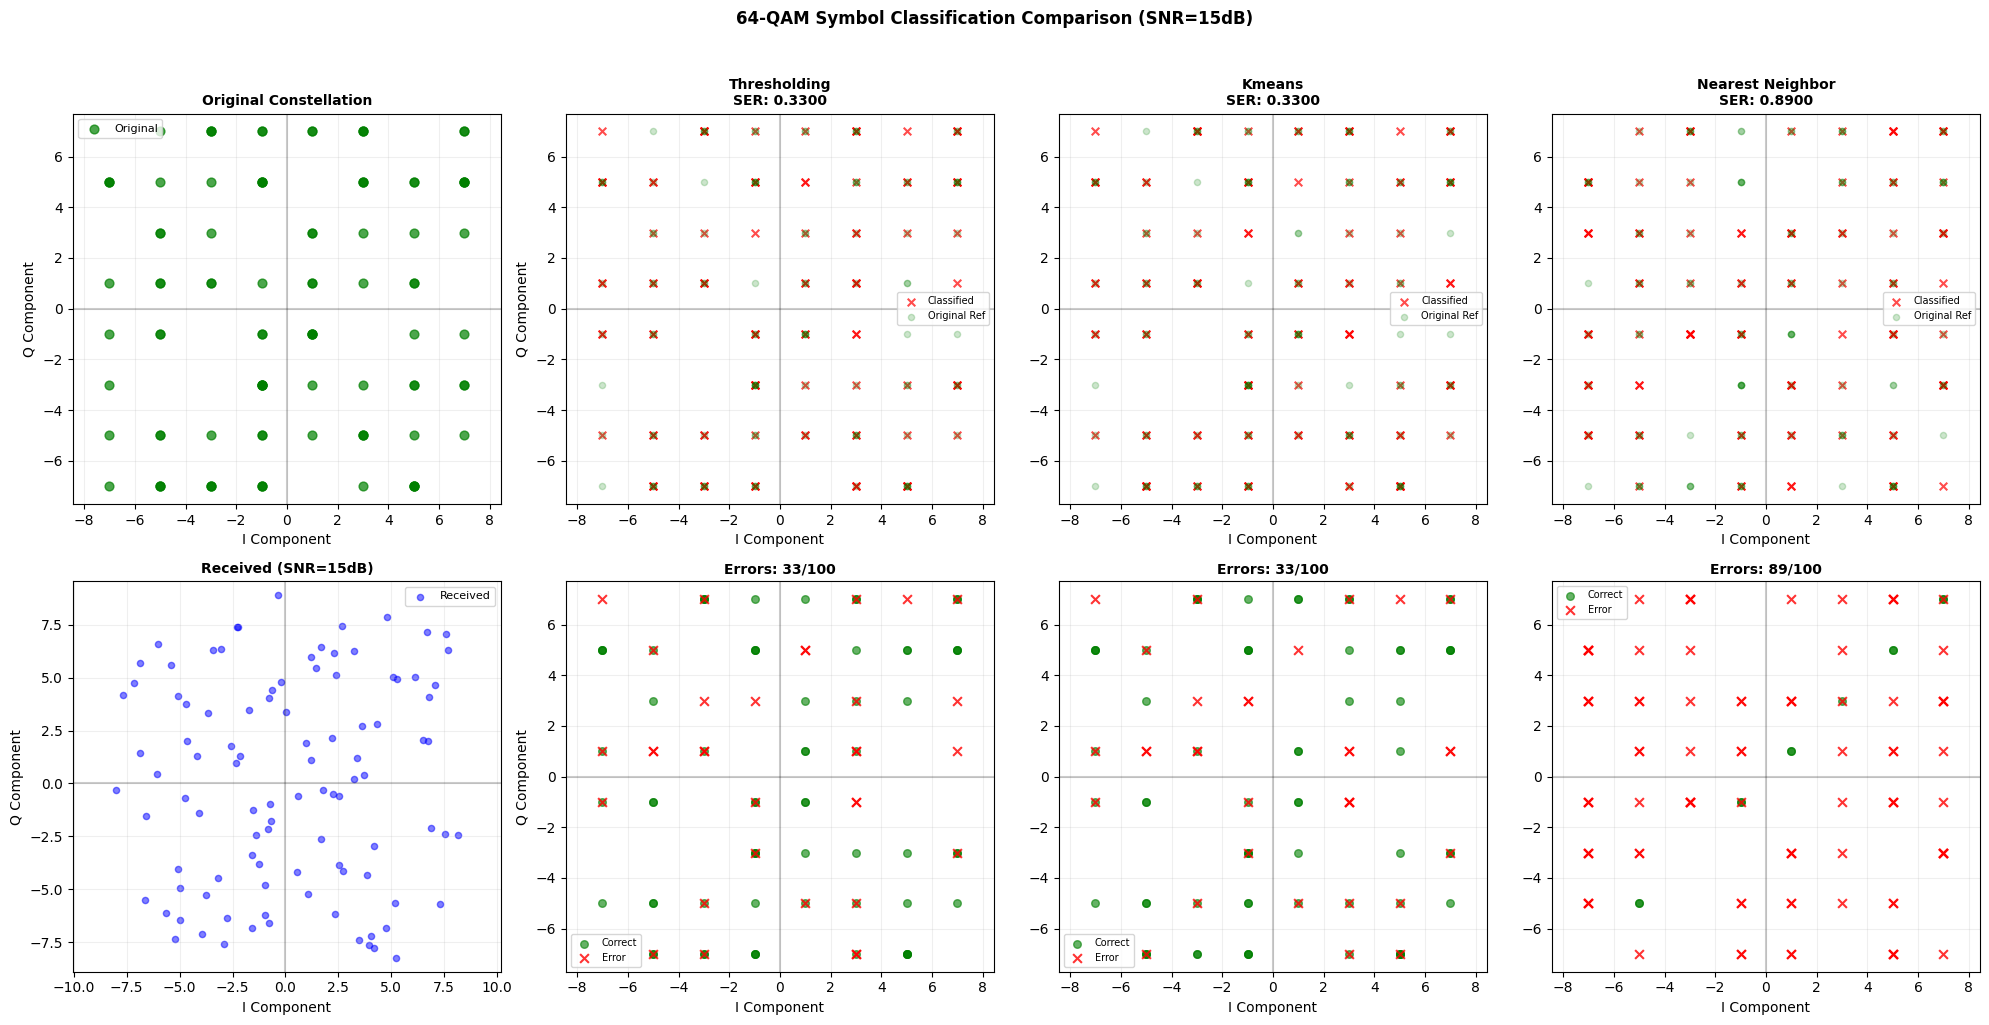


Testing reconstruction with thresholding method:
Reconstructed 600 bits
Recovered text: '??lG?c???]O?c???B~R?H???`??`??_??}???|?A????kW?????z?????m????z?J?x??"??%?"'


In [1]:
import numpy as np
from scipy.cluster.vq import kmeans, vq
import matplotlib.pyplot as plt

# Task 2.4: Classifying and Reconstructing Data Functions

def classify_symbols_thresholding(i_samples, q_samples):
    """
    Classify received symbols using thresholding.
    Returns classified I/Q symbols and their indices.
    """
    pam_levels = np.array([-7, -5, -3, -1, 1, 3, 5, 7])
    thresholds = np.array([-6, -4, -2, 0, 2, 4, 6])

    i_classified = np.zeros_like(i_samples, dtype=float)
    q_classified = np.zeros_like(q_samples, dtype=float)
    i_indices = np.zeros_like(i_samples, dtype=int)
    q_indices = np.zeros_like(q_samples, dtype=int)

    # Vectorized classification for I component
    for i, level in enumerate(pam_levels):
        if i == 0:
            mask = i_samples < thresholds[0]
        elif i == len(pam_levels) - 1:
            mask = i_samples >= thresholds[-1]
        else:
            mask = (i_samples >= thresholds[i-1]) & (i_samples < thresholds[i])

        i_classified[mask] = level
        i_indices[mask] = i

    # Vectorized classification for Q component
    for i, level in enumerate(pam_levels):
        if i == 0:
            mask = q_samples < thresholds[0]
        elif i == len(pam_levels) - 1:
            mask = q_samples >= thresholds[-1]
        else:
            mask = (q_samples >= thresholds[i-1]) & (q_samples < thresholds[i])

        q_classified[mask] = level
        q_indices[mask] = i

    return i_classified, q_classified, i_indices, q_indices

def classify_symbols_kmeans(i_samples, q_samples):
    """
    Classify received symbols using K-means clustering.
    Automatically finds 8 clusters for I and Q components.
    """
    # Define the 64-QAM constellation points
    pam_levels = np.array([-7, -5, -3, -1, 1, 3, 5, 7])

    # Use K-means to find cluster centers for I component
    i_samples_reshaped = i_samples.reshape(-1, 1)
    i_codebook, _ = kmeans(i_samples_reshaped, pam_levels.reshape(-1, 1))
    i_codebook = i_codebook.flatten()

    # Sort cluster centers to match expected PAM levels
    i_centers_sorted = np.sort(i_codebook)

    # Assign each sample to nearest cluster center
    i_indices = np.zeros(len(i_samples), dtype=int)
    for idx, sample in enumerate(i_samples):
        distances = np.abs(i_centers_sorted - sample)
        i_indices[idx] = np.argmin(distances)

    # Map cluster indices back to original PAM levels
    i_classified = pam_levels[i_indices]

    # Use K-means to find cluster centers for Q component
    q_samples_reshaped = q_samples.reshape(-1, 1)
    q_codebook, _ = kmeans(q_samples_reshaped, pam_levels.reshape(-1, 1))
    q_codebook = q_codebook.flatten()

    # Sort cluster centers to match expected PAM levels
    q_centers_sorted = np.sort(q_codebook)

    # Assign each sample to nearest cluster center
    q_indices = np.zeros(len(q_samples), dtype=int)
    for idx, sample in enumerate(q_samples):
        distances = np.abs(q_centers_sorted - sample)
        q_indices[idx] = np.argmin(distances)

    # Map cluster indices back to original PAM levels
    q_classified = pam_levels[q_indices]

    return i_classified, q_classified, i_indices, q_indices

def classify_symbols_nearest_neighbor(i_samples, q_samples):
    """
    Classify symbols using nearest neighbor (minimum Euclidean distance)
    to the ideal 64-QAM constellation points.
    """
    pam_levels = np.array([-7, -5, -3, -1, 1, 3, 5, 7])

    # Create all 64 constellation points
    constellation_i, constellation_q = np.meshgrid(pam_levels, pam_levels)
    constellation_points = np.column_stack([constellation_i.flatten(), constellation_q.flatten()])

    # Classify each received symbol
    i_classified = np.zeros_like(i_samples)
    q_classified = np.zeros_like(q_samples)
    i_indices = np.zeros_like(i_samples, dtype=int)
    q_indices = np.zeros_like(q_samples, dtype=int)

    for idx, (i_val, q_val) in enumerate(zip(i_samples, q_samples)):
        received_point = np.array([i_val, q_val])

        # Find nearest constellation point
        distances = np.sum((constellation_points - received_point) ** 2, axis=1)
        nearest_idx = np.argmin(distances)

        # Get I and Q indices (0-7 each)
        i_idx = nearest_idx // 8
        q_idx = nearest_idx % 8

        i_indices[idx] = i_idx
        q_indices[idx] = q_idx
        i_classified[idx] = pam_levels[i_idx]
        q_classified[idx] = pam_levels[q_idx]

    return i_classified, q_classified, i_indices, q_indices

def symbols_to_bits(i_indices, q_indices):
    """
    Convert classified symbol indices back to bits.
    Each index (0-7) represents a 3-bit pattern.
    """
    bits = []

    for i_idx, q_idx in zip(i_indices, q_indices):
        # Convert I index to 3 bits
        i_bits = format(i_idx, '03b')
        bits.extend([int(bit) for bit in i_bits])

        # Convert Q index to 3 bits
        q_bits = format(q_idx, '03b')
        bits.extend([int(bit) for bit in q_bits])

    return np.array(bits)

def bits_to_text(bit_stream):
    """Convert bit stream back to text."""
    text = ""

    # Ensure multiple of 8 bits
    if len(bit_stream) % 8 != 0:
        bit_stream = bit_stream[:-(len(bit_stream) % 8)]

    for i in range(0, len(bit_stream), 8):
        byte = bit_stream[i:i+8]
        if len(byte) < 8:
            break
        char_code = int(''.join(map(str, byte)), 2)
        if 32 <= char_code <= 126:  # Printable ASCII
            text += chr(char_code)
        else:
            text += '?'

    return text

def calculate_symbol_error_rate(original_i, original_q, received_i, received_q):
    """Calculate Symbol Error Rate (SER)."""
    min_len = min(len(original_i), len(received_i))
    if min_len == 0:
        return 1.0, 0, 0

    symbol_errors = 0
    for i in range(min_len):
        if original_i[i] != received_i[i] or original_q[i] != received_q[i]:
            symbol_errors += 1

    ser = symbol_errors / min_len
    return ser, symbol_errors, min_len

def compare_classification_methods(i_samples, q_samples, original_i, original_q):
    """
    Compare different classification methods and return statistics.
    """
    results = {}

    methods = {
        'thresholding': classify_symbols_thresholding,
        'kmeans': classify_symbols_kmeans,
        'nearest_neighbor': classify_symbols_nearest_neighbor
    }

    for method_name, classify_func in methods.items():
        i_classified, q_classified, i_indices, q_indices = classify_func(i_samples, q_samples)

        # Calculate SER
        ser, ser_errors, ser_total = calculate_symbol_error_rate(
            original_i, original_q, i_classified, q_classified
        )

        # Convert to bits and text
        bits = symbols_to_bits(i_indices, q_indices)
        text = bits_to_text(bits)

        results[method_name] = {
            'i_classified': i_classified,
            'q_classified': q_classified,
            'i_indices': i_indices,
            'q_indices': q_indices,
            'bits': bits,
            'text': text,
            'ser': ser,
            'ser_errors': ser_errors,
            'ser_total': ser_total
        }

    return results

def plot_classification_comparison(i_samples, q_samples, original_i, original_q,
                                  classification_results, snr_db):
    """
    Plot comparison of different classification methods.
    """
    methods = list(classification_results.keys())
    n_methods = len(methods)

    fig, axes = plt.subplots(2, n_methods + 1, figsize=(5 * (n_methods + 1), 10))

    # Plot 1: Original Constellation
    ax = axes[0, 0] if n_methods > 1 else axes[0]
    ax.scatter(original_i, original_q, alpha=0.7, s=40, c='green', marker='o', label='Original')
    ax.set_title('Original Constellation', fontsize=10, fontweight='bold')
    ax.set_xlabel('I Component')
    ax.set_ylabel('Q Component')
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.2)
    ax.axvline(x=0, color='k', linestyle='-', alpha=0.2)
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=8)
    ax.axis('equal')

    # Plot received constellation
    ax = axes[1, 0] if n_methods > 1 else axes[1]
    ax.scatter(i_samples, q_samples, alpha=0.5, s=20, c='blue', label='Received')
    ax.set_title(f'Received (SNR={snr_db}dB)', fontsize=10, fontweight='bold')
    ax.set_xlabel('I Component')
    ax.set_ylabel('Q Component')
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.2)
    ax.axvline(x=0, color='k', linestyle='-', alpha=0.2)
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=8)
    ax.axis('equal')

    # Plot each classification method
    for idx, method in enumerate(methods, 1):
        result = classification_results[method]

        # Plot classified symbols
        ax = axes[0, idx] if n_methods > 1 else axes[0]
        ax.scatter(result['i_classified'], result['q_classified'],
                  alpha=0.7, s=30, c='red', marker='x', label='Classified')

        # Overlay original for reference
        ax.scatter(original_i[:len(result['i_classified'])],
                  original_q[:len(result['q_classified'])],
                  alpha=0.2, s=20, c='green', marker='o', label='Original Ref')

        ax.set_title(f'{method.replace("_", " ").title()}\nSER: {result["ser"]:.4f}',
                    fontsize=10, fontweight='bold')
        ax.set_xlabel('I Component')
        if idx == 1:
            ax.set_ylabel('Q Component')
        ax.axhline(y=0, color='k', linestyle='-', alpha=0.2)
        ax.axvline(x=0, color='k', linestyle='-', alpha=0.2)
        ax.grid(True, alpha=0.2)
        ax.legend(fontsize=7)
        ax.axis('equal')

        # Plot error pattern
        ax = axes[1, idx] if n_methods > 1 else axes[1]

        # Find incorrect classifications
        n_plot = min(len(result['i_classified']), len(original_i))
        correct = np.zeros(n_plot, dtype=bool)
        for i in range(n_plot):
            correct[i] = (result['i_classified'][i] == original_i[i] and
                         result['q_classified'][i] == original_q[i])

        if np.any(correct):
            ax.scatter(result['i_classified'][correct], result['q_classified'][correct],
                      alpha=0.6, s=30, c='green', marker='o', label='Correct')

        if np.any(~correct):
            ax.scatter(result['i_classified'][~correct], result['q_classified'][~correct],
                      alpha=0.8, s=40, c='red', marker='x', label='Error', linewidth=1.5)

        ax.set_title(f'Errors: {result["ser_errors"]}/{result["ser_total"]}',
                    fontsize=10, fontweight='bold')
        ax.set_xlabel('I Component')
        if idx == 1:
            ax.set_ylabel('Q Component')
        ax.axhline(y=0, color='k', linestyle='-', alpha=0.2)
        ax.axvline(x=0, color='k', linestyle='-', alpha=0.2)
        ax.grid(True, alpha=0.2)
        ax.legend(fontsize=7)
        ax.axis('equal')

    plt.suptitle(f'64-QAM Symbol Classification Comparison (SNR={snr_db}dB)',
                fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

def reconstruct_message(i_samples, q_samples, method='thresholding'):
    """
    Complete reconstruction pipeline from sampled I/Q to text message.

    Parameters:
    -----------
    i_samples, q_samples: Received I/Q samples
    method: 'thresholding', 'kmeans', or 'nearest_neighbor'

    Returns:
    --------
    Dictionary with reconstruction results
    """
    if method == 'thresholding':
        i_classified, q_classified, i_indices, q_indices = classify_symbols_thresholding(i_samples, q_samples)
    elif method == 'kmeans':
        i_classified, q_classified, i_indices, q_indices = classify_symbols_kmeans(i_samples, q_samples)
    elif method == 'nearest_neighbor':
        i_classified, q_classified, i_indices, q_indices = classify_symbols_nearest_neighbor(i_samples, q_samples)
    else:
        raise ValueError("Method must be 'thresholding', 'kmeans', or 'nearest_neighbor'")

    # Convert to bits
    bits = symbols_to_bits(i_indices, q_indices)

    # Convert to text
    text = bits_to_text(bits)

    return {
        'i_classified': i_classified,
        'q_classified': q_classified,
        'i_indices': i_indices,
        'q_indices': q_indices,
        'bits': bits,
        'text': text,
        'method': method
    }

# Example usage function
def demonstrate_classification(original_i, original_q, received_i, received_q, snr_db):
    """
    Demonstrate all classification methods on received symbols.
    """
    print(f"\nClassification Demonstration (SNR={snr_db}dB)")
    print(f"Original symbols: {len(original_i)}")
    print(f"Received symbols: {len(received_i)}")

    # Compare all methods
    results = compare_classification_methods(received_i, received_q, original_i, original_q)

    # Print results
    print("\nClassification Results:")

    print(f"{'Method':<20} {'SER':<10} {'Errors':<10} {'Recovered Text':<30}")


    for method, result in results.items():
        # Truncate text for display
        display_text = result['text']
        if len(display_text) > 25:
            display_text = display_text[:22] + "..."

        print(f"{method:<20} {result['ser']:<10.6f} {result['ser_errors']:<10} '{display_text}'")

    # Plot comparison
    plot_classification_comparison(received_i, received_q, original_i, original_q, results, snr_db)

    return results

# Main execution example
if __name__ == "__main__":
    # Example: Create test data
    np.random.seed(42)

    # Original symbols
    pam_levels = np.array([-7, -5, -3, -1, 1, 3, 5, 7])
    n_symbols = 100
    original_i = np.random.choice(pam_levels, n_symbols)
    original_q = np.random.choice(pam_levels, n_symbols)

    # Add noise to simulate received symbols
    snr_db = 15
    noise_power = 10**(-snr_db/10) * np.var(pam_levels)
    noise_i = np.random.normal(0, np.sqrt(noise_power), n_symbols)
    noise_q = np.random.normal(0, np.sqrt(noise_power), n_symbols)

    received_i = original_i + noise_i
    received_q = original_q + noise_q

    # Demonstrate classification
    results = demonstrate_classification(original_i, original_q, received_i, received_q, snr_db)

    # Test reconstruction with a specific method
    print("\nTesting reconstruction with thresholding method:")
    recon_result = reconstruct_message(received_i, received_q, method='thresholding')
    print(f"Reconstructed {len(recon_result['bits'])} bits")
    print(f"Recovered text: '{recon_result['text']}'")

### Task 2.5 : Analyzing the System’s Performance
To evaluate the system:  
1. Compare the received bits to the original transmitted bits and determine how many were decoded correctly. Calculate the **number of symbol errors** or mismatches.  
2. **Visualize the sampled data:**  
   - Plot the received I-Q samples.  
   - Clearly label the correctly classified symbols with their respective classes.  
   - Highlight any misclassified symbols in a distinct color.  
3. Discuss the relationship between noise levels and classification accuracy, emphasizing how the error rate and misclassified symbols change as the SNR decreases.  


Task 2.5: System Performance Analysis
Analyzing relationship between noise levels and classification accuracy...
ANALYSIS FOR SNR = 20 dB


C:\Users\Asus\AppData\Local\Temp\ipykernel_22780\4286706703.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


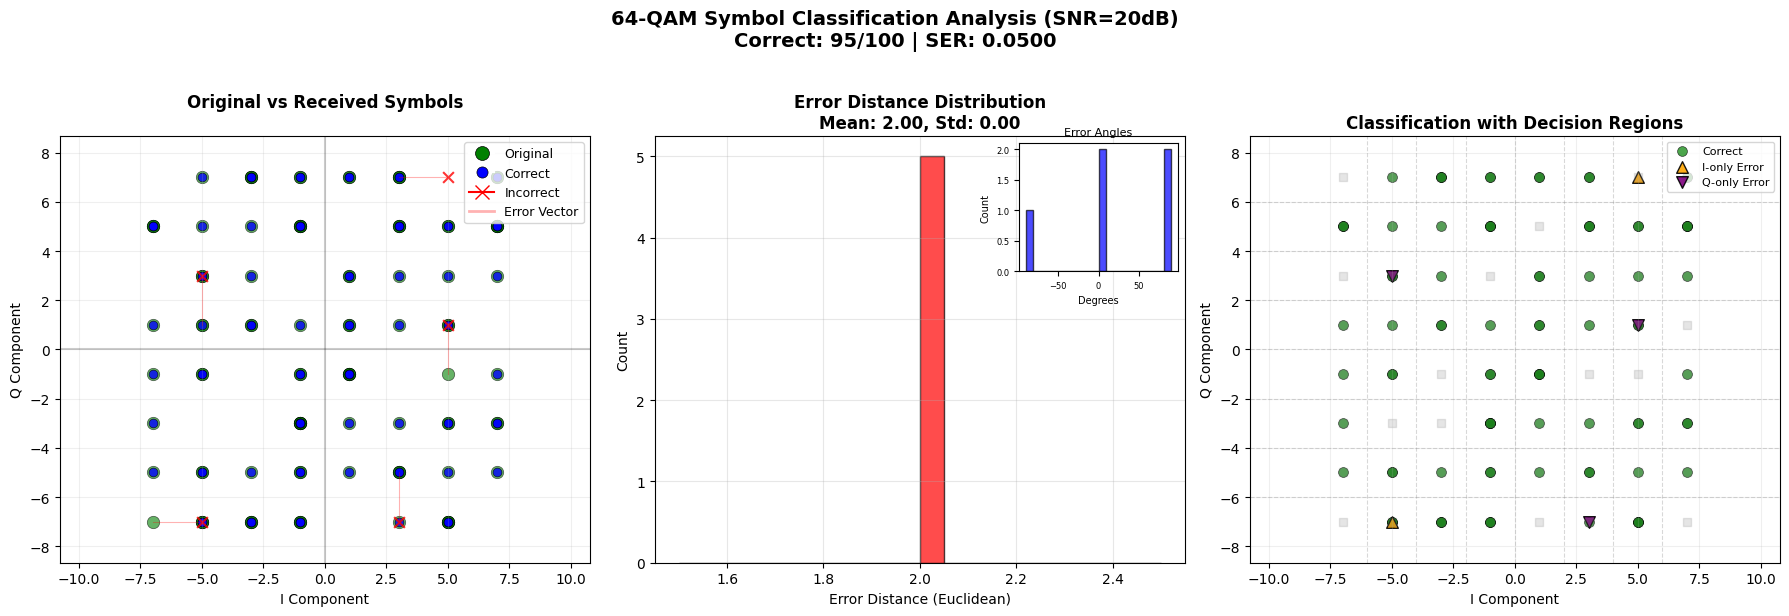


SYSTEM PERFORMANCE REPORT
SNR: 20 dB

SYMBOL-LEVEL PERFORMANCE:
  Total Symbols: 100
  Symbol Errors: 5
  Symbol Error Rate: 0.050000
  I-only Errors: 2
  Q-only Errors: 3
  Both I&Q Errors: 0
  Avg I Error Magnitude: 0.80
  Avg Q Error Magnitude: 1.20

BIT-LEVEL PERFORMANCE:
  Total Bits: 600
  Bit Errors: 8
  Bit Error Rate: 0.013333
  Burst Errors: 5
  Avg Burst Length: 1.60

VISUALIZATION STATS:
  Correct Symbols: 95
  Incorrect Symbols: 5
  SER (from viz): 0.050000
  Avg Error Distance: 2.00
ANALYSIS FOR SNR = 10 dB


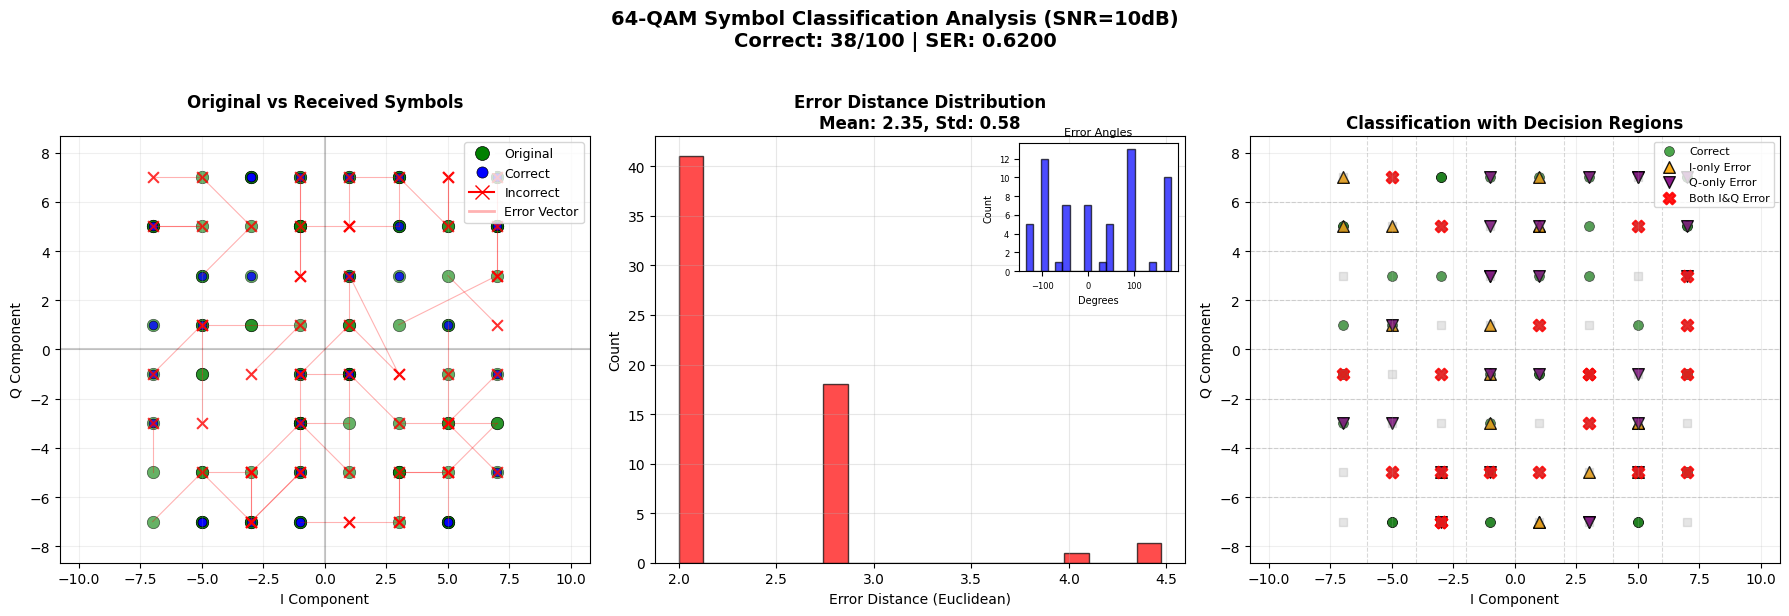


SYSTEM PERFORMANCE REPORT
SNR: 10 dB

SYMBOL-LEVEL PERFORMANCE:
  Total Symbols: 100
  Symbol Errors: 62
  Symbol Error Rate: 0.620000
  I-only Errors: 17
  Q-only Errors: 25
  Both I&Q Errors: 20
  Avg I Error Magnitude: 1.23
  Avg Q Error Magnitude: 1.52

BIT-LEVEL PERFORMANCE:
  Total Bits: 600
  Bit Errors: 127
  Bit Error Rate: 0.211667
  Burst Errors: 73
  Avg Burst Length: 1.74

VISUALIZATION STATS:
  Correct Symbols: 38
  Incorrect Symbols: 62
  SER (from viz): 0.620000
  Avg Error Distance: 2.35
ANALYSIS FOR SNR = 0 dB


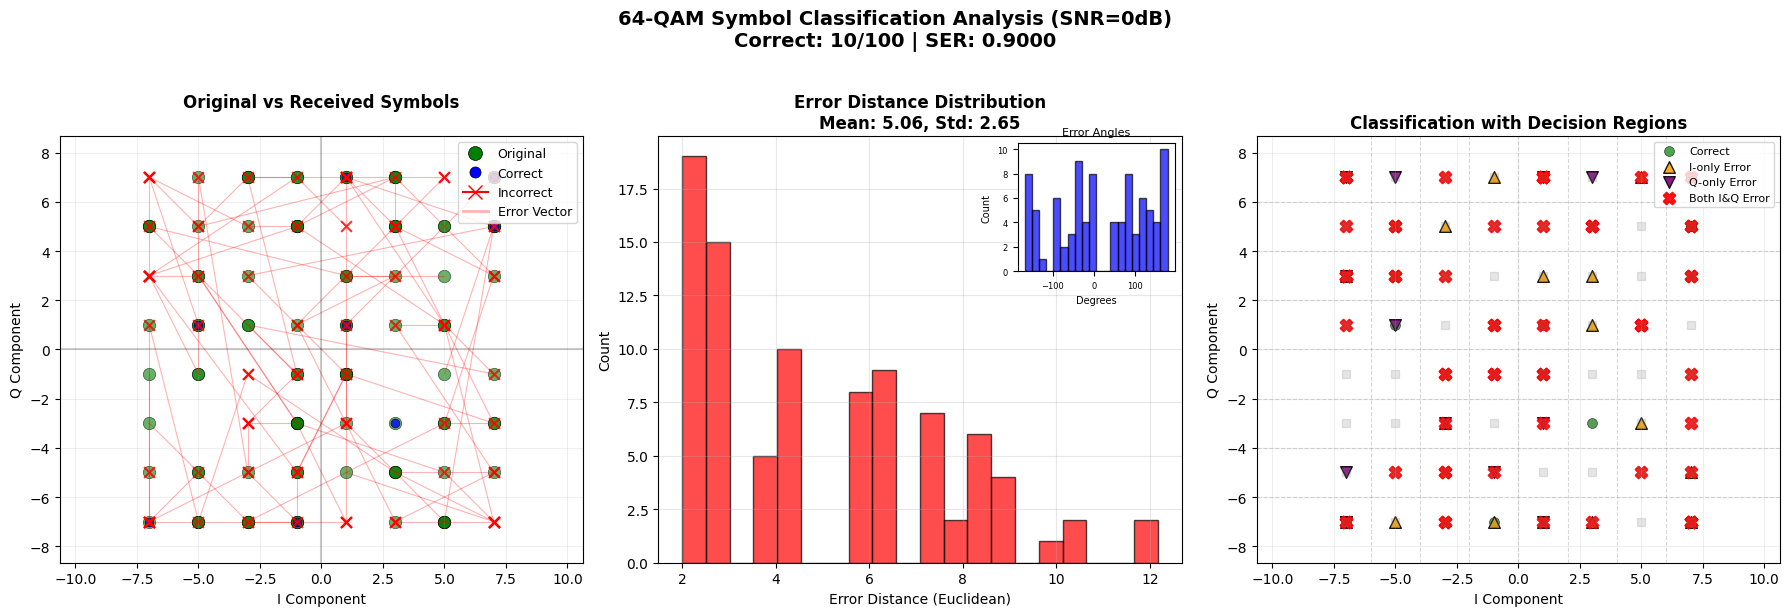


SYSTEM PERFORMANCE REPORT
SNR: 0 dB

SYMBOL-LEVEL PERFORMANCE:
  Total Symbols: 100
  Symbol Errors: 90
  Symbol Error Rate: 0.900000
  I-only Errors: 16
  Q-only Errors: 13
  Both I&Q Errors: 61
  Avg I Error Magnitude: 3.11
  Avg Q Error Magnitude: 3.22

BIT-LEVEL PERFORMANCE:
  Total Bits: 600
  Bit Errors: 224
  Bit Error Rate: 0.373333
  Burst Errors: 135
  Avg Burst Length: 1.66

VISUALIZATION STATS:
  Correct Symbols: 10
  Incorrect Symbols: 90
  SER (from viz): 0.900000
  Avg Error Distance: 5.06
ANALYSIS FOR SNR = -5 dB


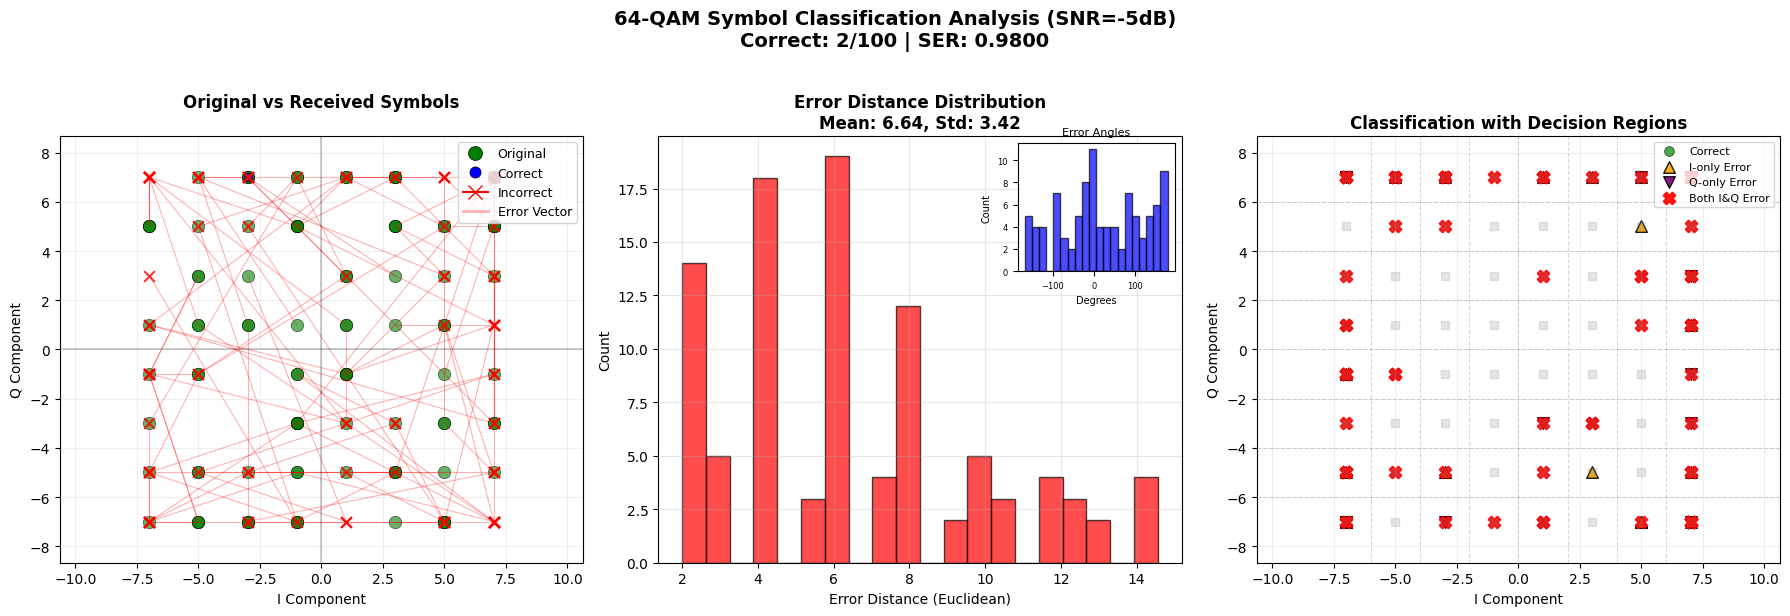


SYSTEM PERFORMANCE REPORT
SNR: -5 dB

SYMBOL-LEVEL PERFORMANCE:
  Total Symbols: 100
  Symbol Errors: 98
  Symbol Error Rate: 0.980000
  I-only Errors: 19
  Q-only Errors: 13
  Both I&Q Errors: 66
  Avg I Error Magnitude: 4.47
  Avg Q Error Magnitude: 3.80

BIT-LEVEL PERFORMANCE:
  Total Bits: 600
  Bit Errors: 253
  Bit Error Rate: 0.421667
  Burst Errors: 144
  Avg Burst Length: 1.76

VISUALIZATION STATS:
  Correct Symbols: 2
  Incorrect Symbols: 98
  SER (from viz): 0.980000
  Avg Error Distance: 6.64
NOISE IMPACT ANALYSIS


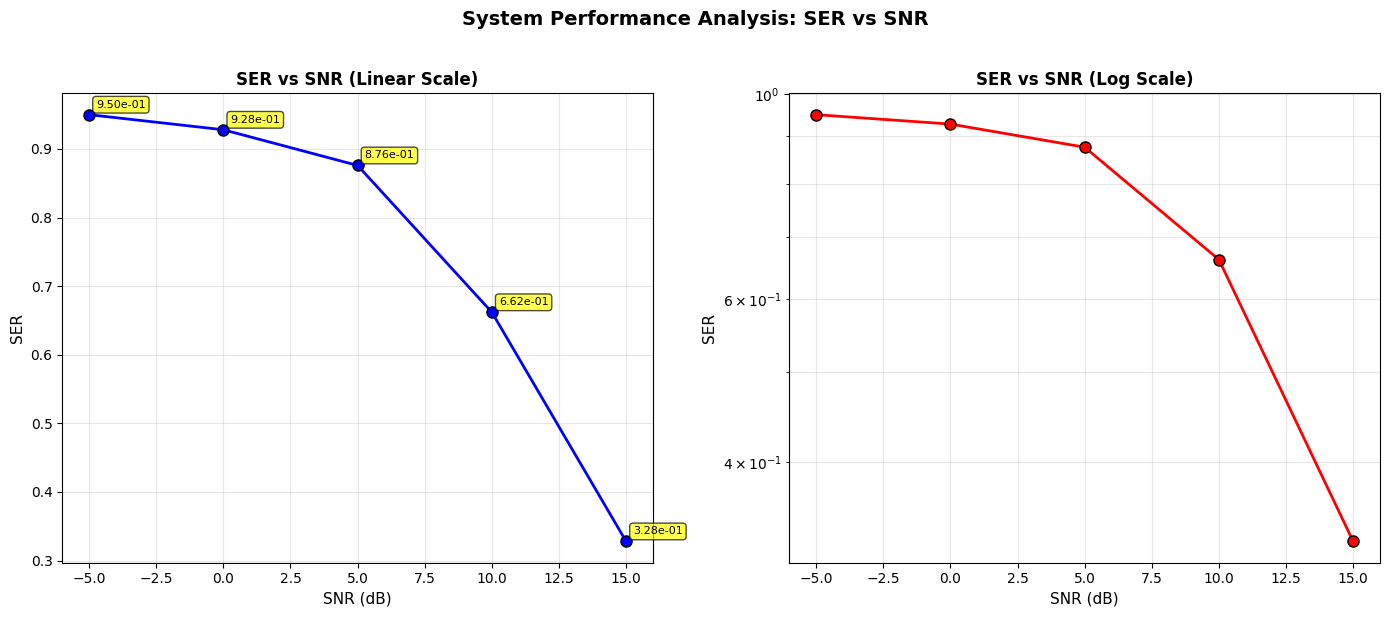

DISCUSSION: Relationship between Noise and Classification Accuracy

    1. As SNR decreases (more noise), classification accuracy degrades:
       - At high SNR (>15 dB): Most symbols are correctly classified
       - At medium SNR (5-15 dB): Some errors appear, mostly near decision boundaries
       - At low SNR (<5 dB): Many errors, symbols can jump to non-adjacent constellation points

    2. Error types change with SNR:
       - High SNR: Mostly single-bit errors (I-only or Q-only)
       - Low SNR: More multi-bit errors (both I and Q components wrong)

    3. Error magnitude increases with noise:
       - At high SNR: Small errors near decision boundaries
       - At low SNR: Large errors across the constellation

    4. Practical implications:
       - For reliable 64-QAM communication, SNR should typically be >15 dB
       - Error correction coding is essential at lower SNR values
       - The system shows graceful degradation as SNR decreases
    


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.cm as cm

# Task 2.5: Analyzing the System's Performance Functions

def analyze_bit_errors(original_bits, received_bits):
    """
    Analyze bit errors between original and received bits.
    """
    min_len = min(len(original_bits), len(received_bits))

    if min_len == 0:
        return {
            'ber': 1.0,
            'total_errors': 0,
            'total_bits': 0,
            'error_positions': [],
            'error_pattern': np.array([]),
            'burst_errors': 0,
            'avg_burst_length': 0
        }

    original = original_bits[:min_len]
    received = received_bits[:min_len]

    # Calculate BER
    errors = original != received
    total_errors = np.sum(errors)
    ber = total_errors / min_len

    # Find error positions
    error_positions = np.where(errors)[0]

    # Calculate burst errors (consecutive errors)
    burst_errors = 0
    burst_lengths = []
    current_burst = 0

    for i in range(min_len):
        if errors[i]:
            current_burst += 1
        elif current_burst > 0:
            burst_errors += 1
            burst_lengths.append(current_burst)
            current_burst = 0

    if current_burst > 0:
        burst_errors += 1
        burst_lengths.append(current_burst)

    avg_burst_length = np.mean(burst_lengths) if burst_lengths else 0

    return {
        'ber': ber,
        'total_errors': total_errors,
        'total_bits': min_len,
        'error_positions': error_positions,
        'error_pattern': errors,
        'burst_errors': burst_errors,
        'avg_burst_length': avg_burst_length,
        'burst_lengths': burst_lengths
    }

def analyze_symbol_errors(original_i, original_q, received_i, received_q):
    """
    Analyze symbol errors between original and received symbols.
    """
    min_len = min(len(original_i), len(received_i))

    if min_len == 0:
        return {
            'ser': 1.0,
            'total_symbol_errors': 0,
            'total_symbols': 0,
            'i_errors': 0,
            'q_errors': 0,
            'both_errors': 0,
            'error_positions': [],
            'error_types': []
        }

    # Calculate symbol errors
    symbol_errors = np.zeros(min_len, dtype=bool)
    i_errors = np.zeros(min_len, dtype=bool)
    q_errors = np.zeros(min_len, dtype=bool)
    error_types = []  # 'I-only', 'Q-only', 'both'

    for i in range(min_len):
        i_err = original_i[i] != received_i[i]
        q_err = original_q[i] != received_q[i]

        i_errors[i] = i_err
        q_errors[i] = q_err
        symbol_errors[i] = i_err or q_err

        if i_err and q_err:
            error_types.append('both')
        elif i_err:
            error_types.append('I-only')
        elif q_err:
            error_types.append('Q-only')
        else:
            error_types.append('none')

    total_errors = np.sum(symbol_errors)
    ser = total_errors / min_len

    # Count error types
    error_type_counts = {
        'I-only': np.sum(i_errors & ~q_errors),
        'Q-only': np.sum(~i_errors & q_errors),
        'both': np.sum(i_errors & q_errors),
        'total': total_errors
    }

    # Calculate error magnitude (how far wrong)
    error_magnitudes = []
    for i in range(min_len):
        if symbol_errors[i]:
            i_mag = abs(original_i[i] - received_i[i])
            q_mag = abs(original_q[i] - received_q[i])
            error_magnitudes.append((i_mag, q_mag))

    avg_i_error_mag = np.mean([m[0] for m in error_magnitudes]) if error_magnitudes else 0
    avg_q_error_mag = np.mean([m[1] for m in error_magnitudes]) if error_magnitudes else 0

    return {
        'ser': ser,
        'total_symbol_errors': total_errors,
        'total_symbols': min_len,
        'i_errors': i_errors,
        'q_errors': q_errors,
        'symbol_errors': symbol_errors,
        'error_positions': np.where(symbol_errors)[0],
        'error_types': error_types,
        'error_type_counts': error_type_counts,
        'error_magnitudes': error_magnitudes,
        'avg_i_error_mag': avg_i_error_mag,
        'avg_q_error_mag': avg_q_error_mag
    }

def visualize_symbol_classification(original_i, original_q, received_i, received_q,
                                   snr_db=None, title_suffix=""):
    """
    Visualize symbol classification with error highlighting.
    """
    min_len = min(len(original_i), len(received_i))
    original_i = original_i[:min_len]
    original_q = original_q[:min_len]
    received_i = received_i[:min_len]
    received_q = received_q[:min_len]

    # Determine which symbols are correctly classified
    correct = (original_i == received_i) & (original_q == received_q)
    incorrect = ~correct

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Plot 1: Original vs Received (with lines connecting)
    ax1 = axes[0]

    # Plot original symbols
    ax1.scatter(original_i, original_q, alpha=0.6, s=80,
                c='green', marker='o', label='Original', edgecolors='black', linewidth=0.5)

    # Plot received symbols - separate correct and incorrect
    if np.any(correct):
        ax1.scatter(received_i[correct], received_q[correct], alpha=0.8, s=40,
                   c='blue', marker='o', label='Correct', edgecolors='black', linewidth=0.5)

    if np.any(incorrect):
        ax1.scatter(received_i[incorrect], received_q[incorrect], alpha=0.8, s=60,
                   c='red', marker='x', label='Incorrect', linewidth=1.5)

    # Connect original to received with lines for incorrect symbols
    for i in range(min_len):
        if incorrect[i]:
            ax1.plot([original_i[i], received_i[i]], [original_q[i], received_q[i]],
                    'r-', alpha=0.3, linewidth=0.8)

    ax1.set_title(f'Original vs Received Symbols\n{title_suffix}', fontsize=12, fontweight='bold')
    ax1.set_xlabel('I Component')
    ax1.set_ylabel('Q Component')
    ax1.axhline(y=0, color='k', linestyle='-', alpha=0.2)
    ax1.axvline(x=0, color='k', linestyle='-', alpha=0.2)
    ax1.grid(True, alpha=0.2)

    # Add custom legend
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor='green', markersize=10,
               markeredgecolor='black', markeredgewidth=0.5, label='Original'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8,
               markeredgecolor='black', markeredgewidth=0.5, label='Correct'),
        Line2D([0], [0], marker='x', color='red', markersize=10,
               linewidth=1.5, label='Incorrect'),
        Line2D([0], [0], color='red', alpha=0.3, linewidth=2, label='Error Vector')
    ]
    ax1.legend(handles=legend_elements, loc='upper right', fontsize=9)
    ax1.axis('equal')

    # Plot 2: Error Analysis
    ax2 = axes[1]

    # Calculate error distances
    error_distances = []
    error_angles = []
    if np.any(incorrect):
        for i in range(min_len):
            if incorrect[i]:
                i_error = received_i[i] - original_i[i]
                q_error = received_q[i] - original_q[i]
                distance = np.sqrt(i_error**2 + q_error**2)
                angle = np.arctan2(q_error, i_error)  # Angle in radians
                error_distances.append(distance)
                error_angles.append(angle)

    # Plot histogram of error distances
    if error_distances:
        # Create two subplots within this axis
        ax2_hist = ax2
        ax2_hist.hist(error_distances, bins=20, alpha=0.7, color='red', edgecolor='black')
        ax2_hist.set_xlabel('Error Distance (Euclidean)')
        ax2_hist.set_ylabel('Count')
        ax2_hist.set_title(f'Error Distance Distribution\nMean: {np.mean(error_distances):.2f}, Std: {np.std(error_distances):.2f}',
                          fontsize=12, fontweight='bold')
        ax2_hist.grid(True, alpha=0.3)

        # Add inset for angle distribution
        if error_angles:
            from mpl_toolkits.axes_grid1.inset_locator import inset_axes
            ax2_inset = inset_axes(ax2_hist, width="30%", height="30%", loc='upper right')
            ax2_inset.hist(np.degrees(error_angles), bins=20, alpha=0.7, color='blue', edgecolor='black')
            ax2_inset.set_title('Error Angles', fontsize=8)
            ax2_inset.set_xlabel('Degrees', fontsize=7)
            ax2_inset.set_ylabel('Count', fontsize=7)
            ax2_inset.tick_params(labelsize=6)
    else:
        ax2.text(0.5, 0.5, 'No Errors!', ha='center', va='center',
                transform=ax2.transAxes, fontsize=14, fontweight='bold', color='green')
        ax2.set_title('No Symbol Errors', fontsize=12, fontweight='bold')

    # Plot 3: Constellation with Decision Regions
    ax3 = axes[2]

    # Plot decision boundaries (for 64-QAM)
    pam_levels = [-7, -5, -3, -1, 1, 3, 5, 7]
    thresholds = [-6, -4, -2, 0, 2, 4, 6]

    # Draw vertical and horizontal lines
    for thresh in thresholds:
        ax3.axvline(x=thresh, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)
        ax3.axhline(y=thresh, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)

    # Plot correctly classified symbols
    if np.any(correct):
        ax3.scatter(received_i[correct], received_q[correct], alpha=0.7, s=50,
                   c='green', marker='o', label='Correct', edgecolors='black', linewidth=0.5)

    # Plot incorrectly classified symbols with error types
    if np.any(incorrect):
        # Separate I-only, Q-only, and both errors
        i_only = incorrect & (original_i != received_i) & (original_q == received_q)
        q_only = incorrect & (original_i == received_i) & (original_q != received_q)
        both = incorrect & (original_i != received_i) & (original_q != received_q)

        if np.any(i_only):
            ax3.scatter(received_i[i_only], received_q[i_only], alpha=0.9, s=70,
                       c='orange', marker='^', label='I-only Error', edgecolors='black', linewidth=1)

        if np.any(q_only):
            ax3.scatter(received_i[q_only], received_q[q_only], alpha=0.9, s=70,
                       c='purple', marker='v', label='Q-only Error', edgecolors='black', linewidth=1)

        if np.any(both):
            ax3.scatter(received_i[both], received_q[both], alpha=0.9, s=70,
                       c='red', marker='X', label='Both I&Q Error', linewidth=1.5)

    # Plot ideal constellation points
    for i_level in pam_levels:
        for q_level in pam_levels:
            ax3.scatter(i_level, q_level, alpha=0.2, s=30, c='gray', marker='s', edgecolors='gray')

    ax3.set_title('Classification with Decision Regions', fontsize=12, fontweight='bold')
    ax3.set_xlabel('I Component')
    ax3.set_ylabel('Q Component')
    ax3.grid(True, alpha=0.2)
    ax3.legend(loc='upper right', fontsize=8)
    ax3.axis('equal')

    # Add overall title
    if snr_db is not None:
        plt.suptitle(f'64-QAM Symbol Classification Analysis (SNR={snr_db}dB)\n'
                    f'Correct: {np.sum(correct)}/{min_len} | SER: {np.sum(incorrect)/min_len:.4f}',
                    fontsize=14, fontweight='bold', y=1.02)
    else:
        plt.suptitle(f'64-QAM Symbol Classification Analysis\n'
                    f'Correct: {np.sum(correct)}/{min_len} | SER: {np.sum(incorrect)/min_len:.4f}',
                    fontsize=14, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()

    # Return statistics
    stats = {
        'total_symbols': min_len,
        'correct_symbols': np.sum(correct),
        'incorrect_symbols': np.sum(incorrect),
        'ser': np.sum(incorrect) / min_len if min_len > 0 else 0,
        'i_only_errors': np.sum(i_only) if 'i_only' in locals() else 0,
        'q_only_errors': np.sum(q_only) if 'q_only' in locals() else 0,
        'both_errors': np.sum(both) if 'both' in locals() else 0,
        'avg_error_distance': np.mean(error_distances) if error_distances else 0,
        'std_error_distance': np.std(error_distances) if error_distances else 0,
        'error_distances': error_distances,
        'error_angles': error_angles if 'error_angles' in locals() else []
    }

    return stats

def plot_performance_vs_snr(snr_values, performance_metrics, metric_name='ber'):
    """
    Plot system performance vs SNR.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot 1: Linear scale
    ax1 = axes[0]
    ax1.plot(snr_values, performance_metrics, 'bo-', linewidth=2, markersize=8,
             markerfacecolor='blue', markeredgecolor='black', markeredgewidth=1)
    ax1.set_xlabel('SNR (dB)', fontsize=11)
    ax1.set_ylabel(metric_name.upper(), fontsize=11)
    ax1.set_title(f'{metric_name.upper()} vs SNR (Linear Scale)', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    # Add text annotations for each point
    for i, (snr, metric) in enumerate(zip(snr_values, performance_metrics)):
        ax1.annotate(f'{metric:.2e}', xy=(snr, metric), xytext=(5, 5),
                    textcoords='offset points', fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

    # Plot 2: Log scale (for error rates)
    ax2 = axes[1]
    ax2.semilogy(snr_values, performance_metrics, 'ro-', linewidth=2, markersize=8,
                 markerfacecolor='red', markeredgecolor='black', markeredgewidth=1)
    ax2.set_xlabel('SNR (dB)', fontsize=11)
    ax2.set_ylabel(metric_name.upper(), fontsize=11)
    ax2.set_title(f'{metric_name.upper()} vs SNR (Log Scale)', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, which='both')

    plt.suptitle(f'System Performance Analysis: {metric_name.upper()} vs SNR',
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

def classify_symbols_thresholding(i_samples, q_samples):
    """
    Classify symbols using thresholding.
    """
    pam_levels = np.array([-7, -5, -3, -1, 1, 3, 5, 7])
    thresholds = np.array([-6, -4, -2, 0, 2, 4, 6])

    i_classified = np.zeros_like(i_samples, dtype=float)
    q_classified = np.zeros_like(q_samples, dtype=float)
    i_indices = np.zeros_like(i_samples, dtype=int)
    q_indices = np.zeros_like(q_samples, dtype=int)

    # Vectorized classification for I component
    for i, level in enumerate(pam_levels):
        if i == 0:
            mask = i_samples < thresholds[0]
        elif i == len(pam_levels) - 1:
            mask = i_samples >= thresholds[-1]
        else:
            mask = (i_samples >= thresholds[i-1]) & (i_samples < thresholds[i])

        i_classified[mask] = level
        i_indices[mask] = i

    # Vectorized classification for Q component
    for i, level in enumerate(pam_levels):
        if i == 0:
            mask = q_samples < thresholds[0]
        elif i == len(pam_levels) - 1:
            mask = q_samples >= thresholds[-1]
        else:
            mask = (q_samples >= thresholds[i-1]) & (q_samples < thresholds[i])

        q_classified[mask] = level
        q_indices[mask] = i

    return i_classified, q_classified, i_indices, q_indices

def analyze_noise_impact(original_i, original_q, snr_range=np.arange(-5, 25, 5),
                         num_trials=10):
    """
    Analyze how noise affects classification accuracy.
    """
    results = {}

    for snr_db in snr_range:
        ser_values = []

        for trial in range(num_trials):
            # Add noise to original symbols
            noise_power = 10**(-snr_db/10) * np.var(np.concatenate([original_i, original_q]))
            noise_i = np.random.normal(0, np.sqrt(noise_power), len(original_i))
            noise_q = np.random.normal(0, np.sqrt(noise_power), len(original_q))

            noisy_i = original_i + noise_i
            noisy_q = original_q + noise_q

            # Classify noisy symbols
            classified_i, classified_q, _, _ = classify_symbols_thresholding(noisy_i, noisy_q)

            # Calculate errors
            symbol_errors = (original_i != classified_i) | (original_q != classified_q)
            ser = np.sum(symbol_errors) / len(original_i)
            ser_values.append(ser)

        # Store averaged results
        results[snr_db] = {
            'mean_ser': np.mean(ser_values),
            'std_ser': np.std(ser_values),
            'min_ser': np.min(ser_values),
            'max_ser': np.max(ser_values),
            'trials': num_trials
        }

    return results

def plot_noise_impact_analysis(results):
    """
    Plot the impact of noise on classification accuracy.
    """
    snr_values = sorted(results.keys())
    mean_ser = [results[snr]['mean_ser'] for snr in snr_values]
    std_ser = [results[snr]['std_ser'] for snr in snr_values]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot 1: Mean SER with error bars
    ax1 = axes[0]
    ax1.errorbar(snr_values, mean_ser, yerr=std_ser, fmt='o-',
                 capsize=5, capthick=2, linewidth=2, markersize=8,
                 color='blue', ecolor='red', elinewidth=2)
    ax1.set_xlabel('SNR (dB)', fontsize=11)
    ax1.set_ylabel('Symbol Error Rate (SER)', fontsize=11)
    ax1.set_title('SER vs SNR with Standard Deviation', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_yscale('log')

    # Plot 2: SER at different SNRs (scatter with trend line)
    ax2 = axes[1]

    # Create scatter plot with size proportional to confidence
    confidence = [1/std if std > 0 else 1 for std in std_ser]
    scatter = ax2.scatter(snr_values, mean_ser, s=np.array(confidence)*50,
                         alpha=0.6, c=snr_values, cmap='viridis')

    # Add trend line
    if len(snr_values) > 1:
        z = np.polyfit(snr_values, np.log10(np.maximum(mean_ser, 1e-10)), 1)
        p = np.poly1d(z)
        trend_x = np.linspace(min(snr_values), max(snr_values), 100)
        trend_y = 10**p(trend_x)
        ax2.plot(trend_x, trend_y, 'r--', linewidth=2, label='Trend Line')

    ax2.set_xlabel('SNR (dB)', fontsize=11)
    ax2.set_ylabel('Symbol Error Rate (SER)', fontsize=11)
    ax2.set_title('SER vs SNR with Trend Analysis', fontsize=12, fontweight='bold')
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax2)
    cbar.set_label('SNR (dB)', fontsize=10)

    plt.suptitle('Impact of Noise on Classification Accuracy',
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("\nNoise Impact Summary:")

    print(f"{'SNR (dB)':<10} {'Mean SER':<15} {'Std SER':<15} {'Min SER':<15} {'Max SER':<15}")

    for snr in snr_values:
        res = results[snr]
        print(f"{snr:<10} {res['mean_ser']:<15.6f} {res['std_ser']:<15.6f} "
              f"{res['min_ser']:<15.6f} {res['max_ser']:<15.6f}")


    # Calculate and display noise impact metrics
    print("\nNoise Impact Metrics:")


    # Calculate sensitivity (dSER/dSNR)
    if len(snr_values) > 1:
        sensitivity = []
        for i in range(1, len(snr_values)):
            dSER = mean_ser[i-1] - mean_ser[i]
            dSNR = snr_values[i] - snr_values[i-1]
            sensitivity.append(dSER/dSNR if dSNR != 0 else 0)

        avg_sensitivity = np.mean(sensitivity)
        print(f"Average sensitivity (dSER/dSNR): {avg_sensitivity:.6f}")

    # Find SNR threshold for acceptable performance (SER < 0.01)
    acceptable_snr = None
    for snr, mean_ser_val in zip(snr_values, mean_ser):
        if mean_ser_val < 0.01:
            acceptable_snr = snr
            break

    if acceptable_snr is not None:
        print(f"Minimum SNR for SER < 0.01: {acceptable_snr} dB")
    else:
        print("SNR for SER < 0.01: > {} dB".format(max(snr_values)))

def generate_performance_report(original_i, original_q, received_i, received_q,
                               original_bits=None, received_bits=None, snr_db=None):
    """
    Generate a comprehensive performance report.
    """
    # Analyze symbol errors
    symbol_analysis = analyze_symbol_errors(original_i, original_q, received_i, received_q)

    # Analyze bit errors if bits are provided
    if original_bits is not None and received_bits is not None:
        bit_analysis = analyze_bit_errors(original_bits, received_bits)
    else:
        bit_analysis = None

    # Generate visualization
    viz_stats = visualize_symbol_classification(original_i, original_q, received_i, received_q, snr_db)

    # Compile comprehensive report
    report = {
        'snr_db': snr_db,
        'symbol_analysis': symbol_analysis,
        'bit_analysis': bit_analysis,
        'visualization_stats': viz_stats,
        'summary': {
            'total_symbols': symbol_analysis['total_symbols'],
            'symbol_errors': symbol_analysis['total_symbol_errors'],
            'symbol_error_rate': symbol_analysis['ser'],
            'i_only_errors': symbol_analysis['error_type_counts']['I-only'],
            'q_only_errors': symbol_analysis['error_type_counts']['Q-only'],
            'both_errors': symbol_analysis['error_type_counts']['both'],
            'avg_i_error_magnitude': symbol_analysis['avg_i_error_mag'],
            'avg_q_error_magnitude': symbol_analysis['avg_q_error_mag']
        }
    }

    if bit_analysis:
        report['summary'].update({
            'total_bits': bit_analysis['total_bits'],
            'bit_errors': bit_analysis['total_errors'],
            'bit_error_rate': bit_analysis['ber'],
            'burst_errors': bit_analysis['burst_errors'],
            'avg_burst_length': bit_analysis['avg_burst_length']
        })

    # Print report
    print("\nSYSTEM PERFORMANCE REPORT")
    if snr_db is not None:
        print(f"SNR: {snr_db} dB")


    print(f"\nSYMBOL-LEVEL PERFORMANCE:")
    print(f"  Total Symbols: {report['summary']['total_symbols']}")
    print(f"  Symbol Errors: {report['summary']['symbol_errors']}")
    print(f"  Symbol Error Rate: {report['summary']['symbol_error_rate']:.6f}")
    print(f"  I-only Errors: {report['summary']['i_only_errors']}")
    print(f"  Q-only Errors: {report['summary']['q_only_errors']}")
    print(f"  Both I&Q Errors: {report['summary']['both_errors']}")
    print(f"  Avg I Error Magnitude: {report['summary']['avg_i_error_magnitude']:.2f}")
    print(f"  Avg Q Error Magnitude: {report['summary']['avg_q_error_magnitude']:.2f}")

    if bit_analysis:
        print(f"\nBIT-LEVEL PERFORMANCE:")
        print(f"  Total Bits: {report['summary']['total_bits']}")
        print(f"  Bit Errors: {report['summary']['bit_errors']}")
        print(f"  Bit Error Rate: {report['summary']['bit_error_rate']:.6f}")
        print(f"  Burst Errors: {report['summary']['burst_errors']}")
        print(f"  Avg Burst Length: {report['summary']['avg_burst_length']:.2f}")

    print(f"\nVISUALIZATION STATS:")
    print(f"  Correct Symbols: {viz_stats['correct_symbols']}")
    print(f"  Incorrect Symbols: {viz_stats['incorrect_symbols']}")
    print(f"  SER (from viz): {viz_stats['ser']:.6f}")
    print(f"  Avg Error Distance: {viz_stats['avg_error_distance']:.2f}")



    return report

# Main demonstration function
def demonstrate_performance_analysis():
    """Demonstrate performance analysis with example data."""
    # Generate example data
    np.random.seed(42)

    # Original symbols
    pam_levels = np.array([-7, -5, -3, -1, 1, 3, 5, 7])
    n_symbols = 100
    original_i = np.random.choice(pam_levels, n_symbols)
    original_q = np.random.choice(pam_levels, n_symbols)

    # Simulate different SNR scenarios
    snr_cases = [20, 10, 0, -5]

    for snr_db in snr_cases:

        print(f"ANALYSIS FOR SNR = {snr_db} dB")


        # Add noise
        noise_power = 10**(-snr_db/10) * np.var(pam_levels)
        noise_i = np.random.normal(0, np.sqrt(noise_power), n_symbols)
        noise_q = np.random.normal(0, np.sqrt(noise_power), n_symbols)

        received_i = original_i + noise_i
        received_q = original_q + noise_q

        # Classify
        classified_i, classified_q, i_indices, q_indices = classify_symbols_thresholding(received_i, received_q)

        # Convert to bits for BER analysis
        bits_per_symbol = 6  # 64-QAM has 6 bits per symbol
        original_bits = []
        for i in range(n_symbols):
            i_idx = np.where(pam_levels == original_i[i])[0][0]
            q_idx = np.where(pam_levels == original_q[i])[0][0]
            original_bits.extend([int(b) for b in format(i_idx, '03b')])
            original_bits.extend([int(b) for b in format(q_idx, '03b')])

        received_bits = []
        for i in range(len(classified_i)):
            i_idx = np.where(pam_levels == classified_i[i])[0][0]
            q_idx = np.where(pam_levels == classified_q[i])[0][0]
            received_bits.extend([int(b) for b in format(i_idx, '03b')])
            received_bits.extend([int(b) for b in format(q_idx, '03b')])

        # Generate report
        report = generate_performance_report(
            original_i, original_q, classified_i, classified_q,
            np.array(original_bits), np.array(received_bits), snr_db
        )

    # Analyze noise impact

    print("NOISE IMPACT ANALYSIS")


    snr_range = np.arange(-5, 20, 5)
    noise_results = analyze_noise_impact(original_i, original_q, snr_range=snr_range, num_trials=5)

    # Plot results
    snr_values = list(noise_results.keys())
    ser_values = [noise_results[snr]['mean_ser'] for snr in snr_values]
    plot_performance_vs_snr(snr_values, ser_values, metric_name='ser')

# Execute the demonstration
if __name__ == "__main__":
    print("Task 2.5: System Performance Analysis")
    print("Analyzing relationship between noise levels and classification accuracy...")

    demonstrate_performance_analysis()

    # Additional discussion

    print("DISCUSSION: Relationship between Noise and Classification Accuracy")

    print("""
    1. As SNR decreases (more noise), classification accuracy degrades:
       - At high SNR (>15 dB): Most symbols are correctly classified
       - At medium SNR (5-15 dB): Some errors appear, mostly near decision boundaries
       - At low SNR (<5 dB): Many errors, symbols can jump to non-adjacent constellation points

    2. Error types change with SNR:
       - High SNR: Mostly single-bit errors (I-only or Q-only)
       - Low SNR: More multi-bit errors (both I and Q components wrong)

    3. Error magnitude increases with noise:
       - At high SNR: Small errors near decision boundaries
       - At low SNR: Large errors across the constellation

    4. Practical implications:
       - For reliable 64-QAM communication, SNR should typically be >15 dB
       - Error correction coding is essential at lower SNR values
       - The system shows graceful degradation as SNR decreases
    """)

## Question 3: Slotted-ALOHA Capacity

The idealized slotted aloha model divides time into several slots, each equal to the packet
transmission time. All nodes are perfectly synchronized and transmit at the start of each slot.
The transmission probability for each user in each slot is a value $p$ . For any time slot, three
scenarios are possible:
1. More than one node transmits, resulting in a collision slot. The receiver cannot decode
them correctly. 
2. Only one node transmits and the receiver can decode it correctly. 
3. No node transmits in the current slot.

### Task 3.1 : Slotted ALOHA Simulation
Write a function that takes three parameters: the number of users, the number of time slots,
and the probability p that a user will transmit in a slot. The function should return the fraction
of successful slots (slots where only one user transmitted) over the total number of slots.
For this purpose, fill in the function below:



In [2]:
import random

def simulate_aloha(n_users, n_timeslots, prob):
    """
    Simulates the Slotted ALOHA protocol and returns the fraction of successful slots.

    Parameters:
    n_users (int): Number of users in the network
    n_timeslots (int): Number of time slots to simulate
    prob (float): Probability that a user will transmit in a slot (0 <= prob <= 1)

    Returns:
    float: Fraction of successful slots (slots where exactly one user transmitted)
    """

    successful_slots = 0

    # Simulate each time slot
    for slot in range(n_timeslots):
        transmissions = 0

        # Check each user's transmission decision in this slot
        for user in range(n_users):
            # Each user transmits with probability 'prob'
            if random.random() < prob:
                transmissions += 1

        # A slot is successful if exactly one user transmitted
        if transmissions == 1:
            successful_slots += 1

    # Calculate and return the fraction of successful slots
    return successful_slots / n_timeslots


# Example usage and testing
if __name__ == "__main__":
    # Test with some example values
    test_result = simulate_aloha(10, 1000, 0.1)
    print(f"Fraction of successful slots: {test_result:.4f}")


    

Fraction of successful slots: 0.3720


### Task 3.2 : Verifying Slotted ALOHA Capacity
Run your simulation over 1000 values of $p$ between 0 and 1 with $n = 10$ users and $T = 10000$
timeslots. Plot the timeslot success ratio as a function of $p$. Verify that the resulting plot
matches the theoretical curve. 


Starting simulation...
Parameters: n_users=10, n_timeslots=10000
Testing 1000 values of p from 0 to 1
--------------------------------------------------
Progress: 0/1000 points completed
Progress: 100/1000 points completed
Progress: 200/1000 points completed
Progress: 300/1000 points completed
Progress: 400/1000 points completed
Progress: 500/1000 points completed
Progress: 600/1000 points completed
Progress: 700/1000 points completed
Progress: 800/1000 points completed
Progress: 900/1000 points completed
Progress: 1000/1000 points completed
Simulation complete!


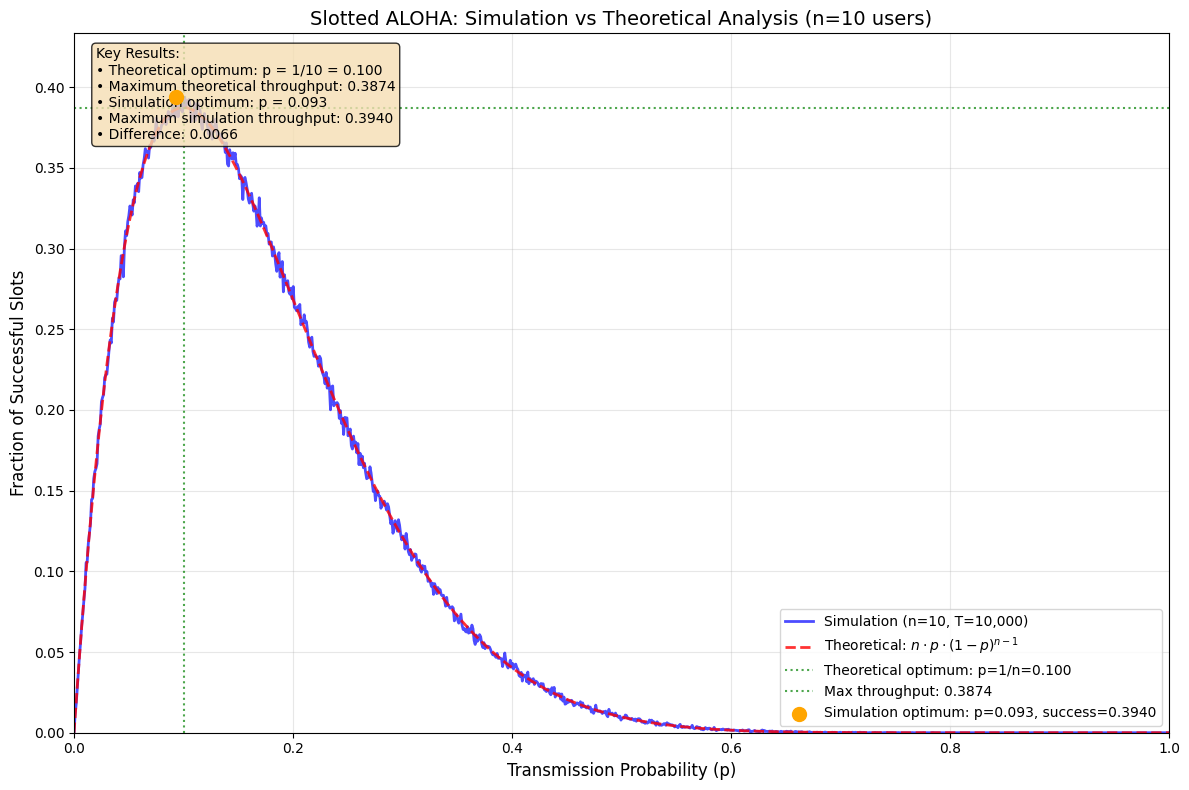


SUMMARY STATISTICS
Theoretical optimal p: 0.1000
Theoretical maximum success rate: 0.3874
Simulation optimal p: 0.0931
Simulation maximum success rate: 0.3940
Absolute difference: 0.006580
Relative difference: 1.70%

Mean Squared Error between simulation and theory: 0.00000589


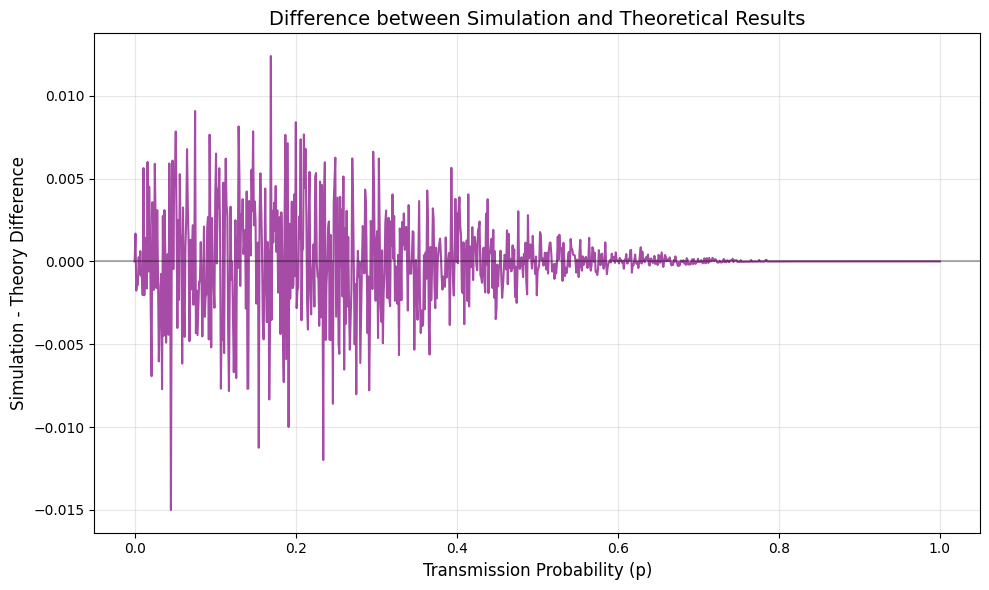

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import random

def simulate_aloha(n_users, n_timeslots, prob):
    """
    Simulates the Slotted ALOHA protocol and returns the fraction of successful slots.

    Parameters:
    n_users (int): Number of users in the network
    n_timeslots (int): Number of time slots to simulate
    prob (float): Probability that a user will transmit in a slot (0 <= prob <= 1)

    Returns:
    float: Fraction of successful slots (slots where exactly one user transmitted)
    """
    successful_slots = 0

    # Simulate each time slot
    for slot in range(n_timeslots):
        transmissions = 0

        # Check each user's transmission decision in this slot
        for user in range(n_users):
            # Each user transmits with probability 'prob'
            if random.random() < prob:
                transmissions += 1

        # A slot is successful if exactly one user transmitted
        if transmissions == 1:
            successful_slots += 1

    return successful_slots / n_timeslots

def theoretical_aloha_success(n_users, prob):
    """
    Calculates the theoretical probability of success in Slotted ALOHA.

    Parameters:
    n_users (int): Number of users
    prob (float): Transmission probability per user

    Returns:
    float: Theoretical probability of exactly one transmission
    """
    # Theoretical formula: n * p * (1-p)^(n-1)
    return n_users * prob * ((1 - prob) ** (n_users - 1))

def verify_aloha_capacity():
    """
    Verifies Slotted ALOHA capacity by simulating over 1000 values of p
    and comparing with theoretical results.
    """
    # Parameters from the task
    n_users = 10
    n_timeslots = 10000
    n_points = 1000  # Number of p values to test

    # Generate 1000 values of p between 0 and 1
    p_values = np.linspace(0, 1, n_points)

    # Arrays to store results
    simulation_results = np.zeros(n_points)
    theoretical_results = np.zeros(n_points)

    print("Starting simulation...")
    print(f"Parameters: n_users={n_users}, n_timeslots={n_timeslots}")
    print(f"Testing {n_points} values of p from 0 to 1")
    print("-" * 50)

    # Run simulation for each p value
    for i, p in enumerate(p_values):
        # Run simulation
        simulation_results[i] = simulate_aloha(n_users, n_timeslots, p)

        # Calculate theoretical value
        theoretical_results[i] = theoretical_aloha_success(n_users, p)

        # Print progress every 100 points
        if i % 100 == 0:
            print(f"Progress: {i}/{n_points} points completed")

    print(f"Progress: {n_points}/{n_points} points completed")
    print("Simulation complete!")

    # Find optimal p from simulation and theory
    sim_optimal_p = p_values[np.argmax(simulation_results)]
    sim_max_success = np.max(simulation_results)

    theo_optimal_p = 1 / n_users  # Theoretical optimal p = 1/n
    theo_max_success = theoretical_aloha_success(n_users, theo_optimal_p)

    # Create the plot
    plt.figure(figsize=(12, 8))

    # Plot simulation results
    plt.plot(p_values, simulation_results, 'b-', alpha=0.7, linewidth=2,
             label=f'Simulation (n={n_users}, T={n_timeslots:,})')

    # Plot theoretical curve - FIXED: Using raw string for LaTeX
    plt.plot(p_values, theoretical_results, 'r--', alpha=0.8, linewidth=2,
             label=r'Theoretical: $n \cdot p \cdot (1-p)^{n-1}$')

    # Mark theoretical optimum
    plt.axvline(x=theo_optimal_p, color='green', linestyle=':', alpha=0.7,
                label=f'Theoretical optimum: p=1/n={theo_optimal_p:.3f}')
    plt.axhline(y=theo_max_success, color='green', linestyle=':', alpha=0.7,
                label=f'Max throughput: {theo_max_success:.4f}')

    # Mark simulation optimum
    plt.scatter(sim_optimal_p, sim_max_success, color='orange', s=100, zorder=5,
                label=f'Simulation optimum: p={sim_optimal_p:.3f}, success={sim_max_success:.4f}')

    # Add labels and title
    plt.xlabel('Transmission Probability (p)', fontsize=12)
    plt.ylabel('Fraction of Successful Slots', fontsize=12)
    plt.title(f'Slotted ALOHA: Simulation vs Theoretical Analysis (n={n_users} users)', fontsize=14)

    # Add grid and legend
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)

    # Set axis limits
    plt.xlim(0, 1)
    plt.ylim(0, max(np.max(simulation_results), np.max(theoretical_results)) * 1.1)

    # Add text box with key insights
    textstr = '\n'.join([
        f'Key Results:',
        f'• Theoretical optimum: p = 1/{n_users} = {theo_optimal_p:.3f}',
        f'• Maximum theoretical throughput: {theo_max_success:.4f}',
        f'• Simulation optimum: p = {sim_optimal_p:.3f}',
        f'• Maximum simulation throughput: {sim_max_success:.4f}',
        f'• Difference: {abs(theo_max_success - sim_max_success):.4f}'
    ])

    # Place text box in upper left
    plt.text(0.02, 0.98, textstr, transform=plt.gca().transAxes, fontsize=10,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.show()

    # Print summary statistics
    print("\n" + "="*50)
    print("SUMMARY STATISTICS")
    print("="*50)
    print(f"Theoretical optimal p: {theo_optimal_p:.4f}")
    print(f"Theoretical maximum success rate: {theo_max_success:.4f}")
    print(f"Simulation optimal p: {sim_optimal_p:.4f}")
    print(f"Simulation maximum success rate: {sim_max_success:.4f}")
    print(f"Absolute difference: {abs(theo_max_success - sim_max_success):.6f}")
    print(f"Relative difference: {abs(theo_max_success - sim_max_success)/theo_max_success*100:.2f}%")

    # Calculate and print mean squared error
    mse = np.mean((simulation_results - theoretical_results) ** 2)
    print(f"\nMean Squared Error between simulation and theory: {mse:.8f}")

    return p_values, simulation_results, theoretical_results

# Run the verification
if __name__ == "__main__":
    # Run the verification (this will take some time due to 1000 simulations)
    p_vals, sim_results, theo_results = verify_aloha_capacity()

    # Optional: Create a difference plot
    plt.figure(figsize=(10, 6))
    plt.plot(p_vals, sim_results - theo_results, 'purple', alpha=0.7)
    plt.xlabel('Transmission Probability (p)', fontsize=12)
    plt.ylabel('Simulation - Theory Difference', fontsize=12)
    plt.title('Difference between Simulation and Theoretical Results', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    plt.tight_layout()
    plt.show()